In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import os
import glob
# import seaborn as sns
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator
from phd_clouds.utils import get_complete_time, assign_season, reading_dataset_chunking

In [2]:
%matplotlib inline
# %matplotlib widget
# Define here plot configuration
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 1
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['axes.titlepad'] = 20  # Raise title
# sans serif
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [3]:
filepath_data = "/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_analysis/cloud_properties" # Path to save the cloud classification files
filepath_cloud_occurence = "/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_analysis/cloud_occurrence" # Path to save the cloud classification files
filepath_cloud_cloud_type = "/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_analysis/cloud_type" 
figure_path = "/media/matheustolen/Seagate Basic/cloud-statistics-data/sensitivity_figures"

# Case by case analysis of total change in frequency and cloud properties

In [5]:
pattern = "*min_ice_percentage.nc"
filenames_occurence  = glob.glob(os.path.join(filepath_cloud_occurence, pattern))
filenames_cloud_type = glob.glob(os.path.join(filepath_cloud_cloud_type, pattern))
filenames_properties = glob.glob(os.path.join(filepath_data, pattern))

In [6]:
# This will combine all files along the 'time' dimension by default
ds_occurence  = xr.open_mfdataset(filenames_occurence, combine='by_coords').compute()
ds_cloud_type = xr.open_mfdataset(filenames_cloud_type, combine='by_coords').compute()
ds_properties = xr.open_mfdataset(filenames_properties, combine='by_coords').compute()

In [46]:
ds_properties.head

<bound method Dataset.head of <xarray.Dataset>
Dimensions:             (time: 3976104, min_ice_percentage: 9)
Coordinates:
  * time                (time) datetime64[ns] 2018-04-23T15:28:45.001144409 ....
  * min_ice_percentage  (min_ice_percentage) int64 60 65 70 75 80 85 90 95 100
Data variables:
    cloud_base          (time, min_ice_percentage) float64 4.474e+03 ... 5.37...
    cloud_top           (time, min_ice_percentage) float64 5.772e+03 ... 1.10...
    cloud_thickness     (time, min_ice_percentage) float64 1.298e+03 ... 5.66...
    lwp                 (time, min_ice_percentage) float64 nan nan ... nan nan>

In [ ]:
cloud_type_str = 'Precipitating-Mixed-Phase'
mask_prop  =(ds_occurence.single_layer == 1 ) & (ds_occurence.attenuation == False) & (ds_cloud_type[cloud_type_str] == 1.)
mask_occur =(ds_cloud_type[cloud_type_str] == 1.)
ds_properties_filtered = ds_properties.where(mask_prop)
ds_occurence_filtered  = ds_occurence.where(mask_occur, 0)

### Statistics

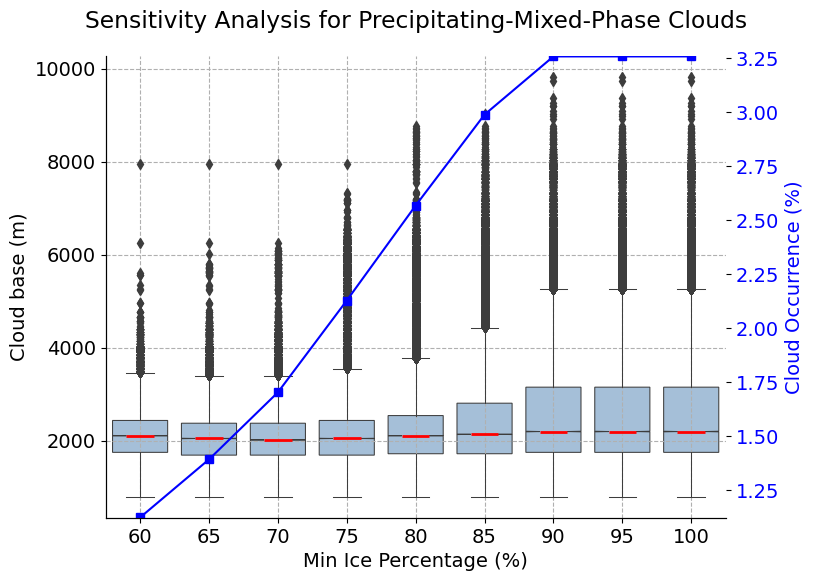

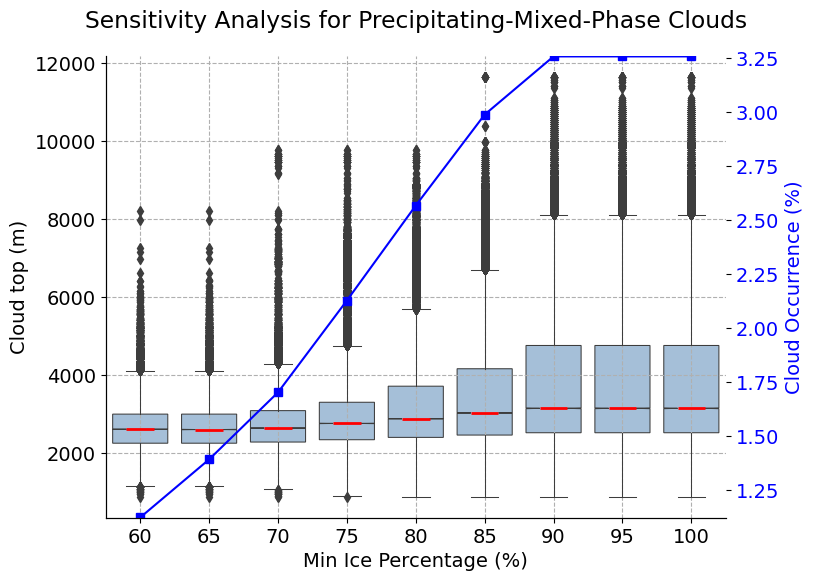

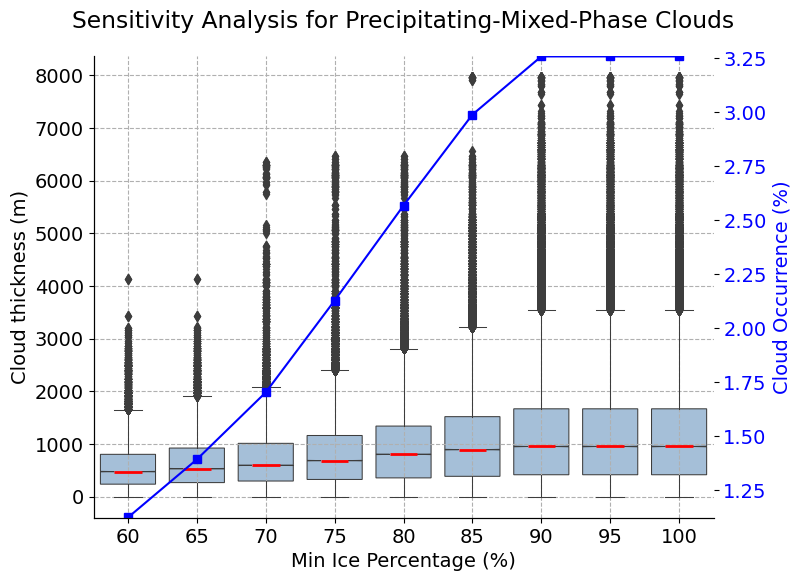

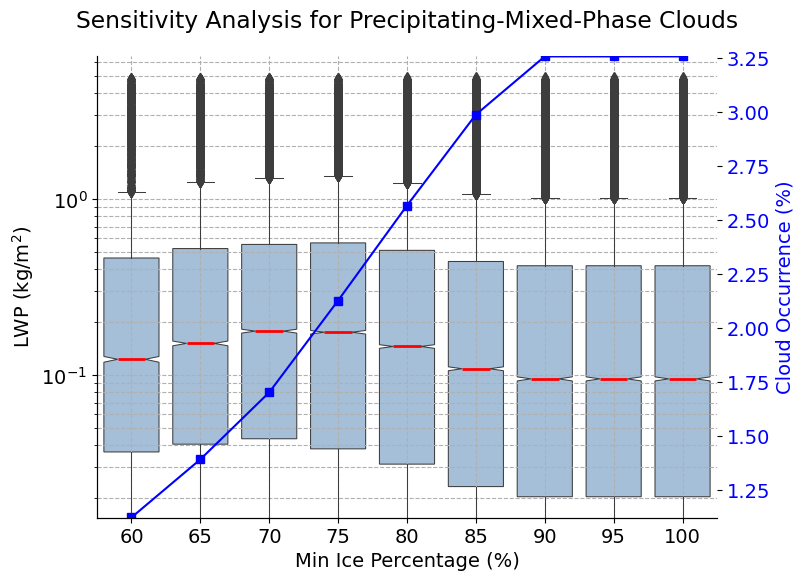

In [18]:
plt.close('all')
data_vars = list(ds_properties_filtered.data_vars)
parameter_names = {'min_liquid_percentage': 'Min Liquid Percentage (%)',
                  'min_ice_percentage': 'Min Ice Percentage (%)',
                  'min_cloudp': 'Min Number of Cloud Pixels (#)',
                  'min_rainp': 'Min Rain Pixels (#)'
                  }
freq_occur   = ds_occurence_filtered['single_layer'].mean(dim='time')*100
number_occur = ds_occurence_filtered['single_layer'].sum(dim='time')
for var in data_vars:
    fig, ax = plt.subplots(figsize=(8,6))
    # plot boxplot for each min_cloudp
    sns.boxplot(x=pattern[1:-3], y=var, 
                data=ds_properties_filtered.to_dataframe().reset_index(),
                notch=True,
                boxprops={"facecolor": (.3, .5, .7, .5)},
                linewidth=.75,
                medianprops={"color": "r", "linewidth": 2}, 
                ax=ax)
    if var == 'lwp':
        ax.set_yscale('log')
        # let all CAPITAL
        ax.set_ylabel(var.replace('_', ' ').upper() + r' (kg/m$^2$)')
    else:
        ax.set_ylabel(var.replace('_', ' ').capitalize() + ' (m)')
    ax.grid(True, which="both", ls="--")
    ax.set_xlabel(parameter_names[pattern[1:-3]])

    ax2 = ax.twinx()
    ax2.plot(freq_occur, color='blue', marker='s', linestyle='-')
    ax2.set_ylabel('Cloud Occurrence (%)', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax2.set_ylim(freq_occur.min()*0.999, freq_occur.max()*1.001)
    ax2.grid(False)

    # remove top end right spines
    ax.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # ax3 = ax.twinx() # Plot number_occur
    # ax3.spines['right'].set_position(('outward', 60))  #
    # ax3.plot(number_occur, color='green', marker='o', linestyle='--')
    # ax3.set_ylabel('Number of Occurrences', color='green')
    # ax3.tick_params(axis='y', labelcolor='green')
    # ax3.set_ylim(number_occur.min()*0.9, number_occur.max()*1.1)
    # ax3.grid(False)

    plt.title(f'Sensitivity Analysis for {cloud_type_str} Clouds')
    plt.show()


# Pertubation analysis:
## Seasonal Analysis for all parameters (reduced)

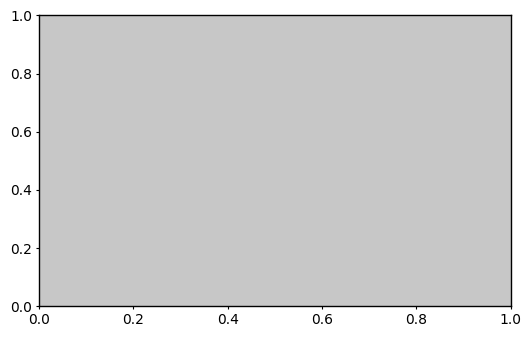

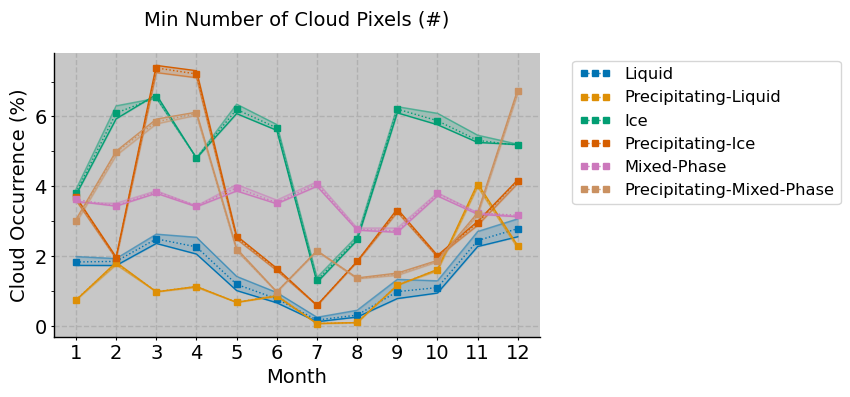

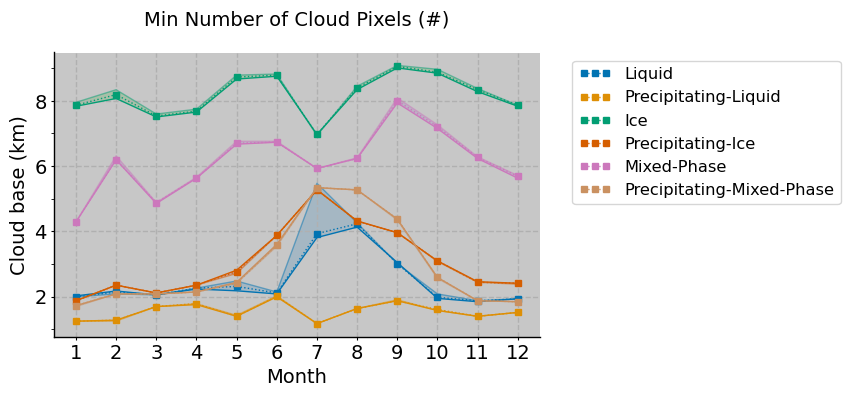

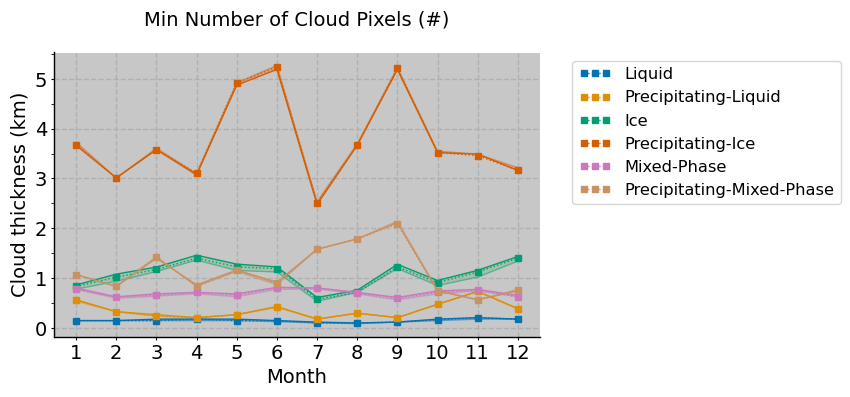

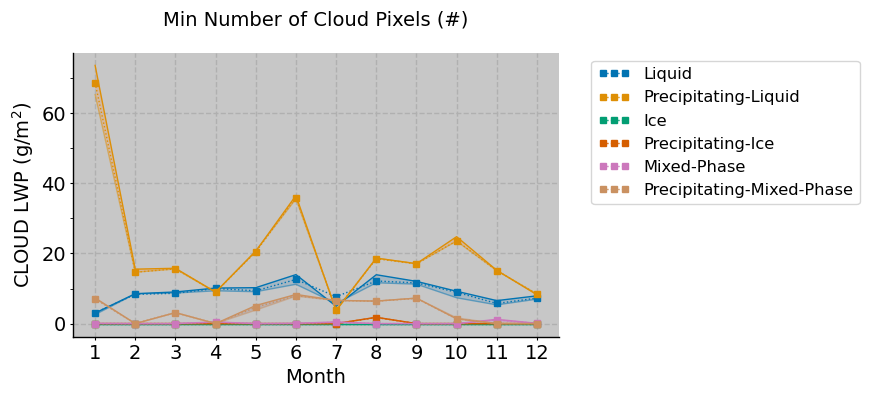

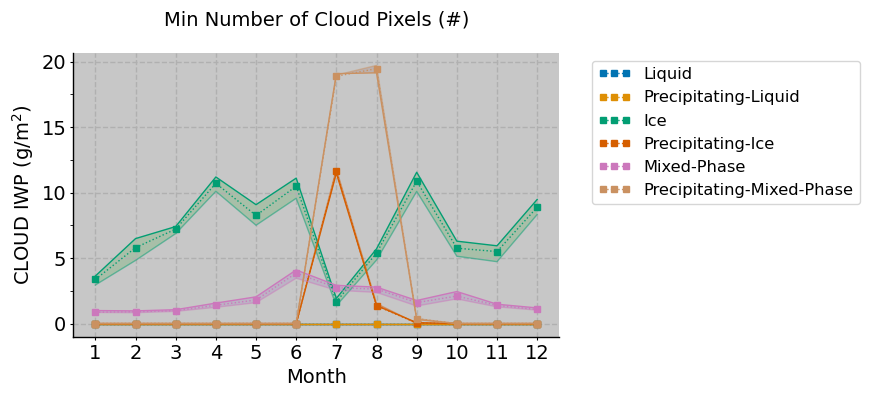

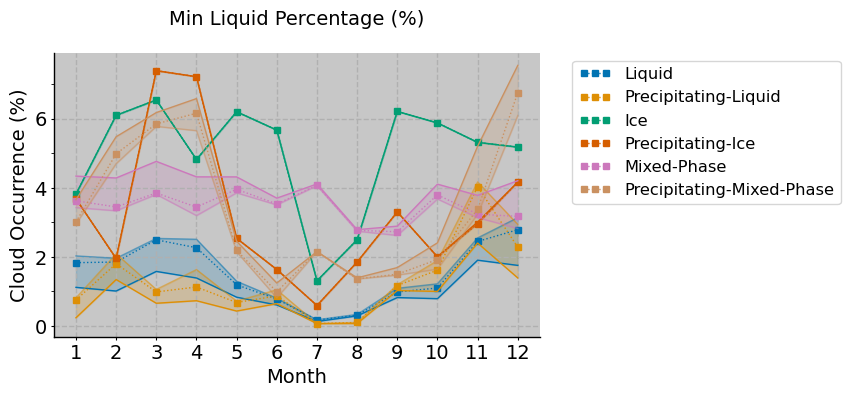

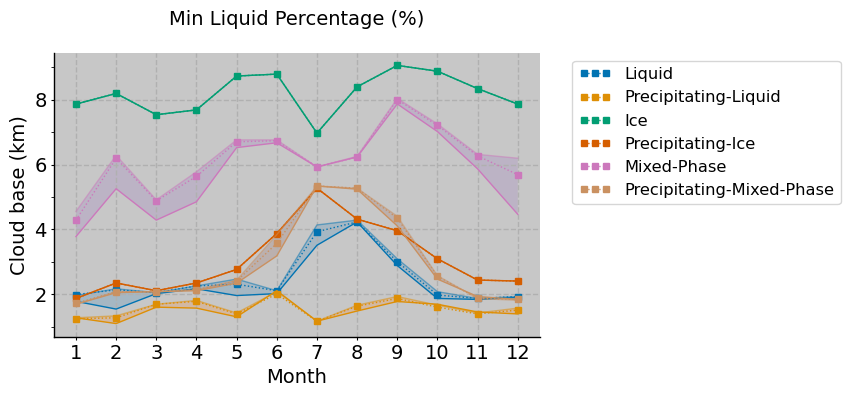

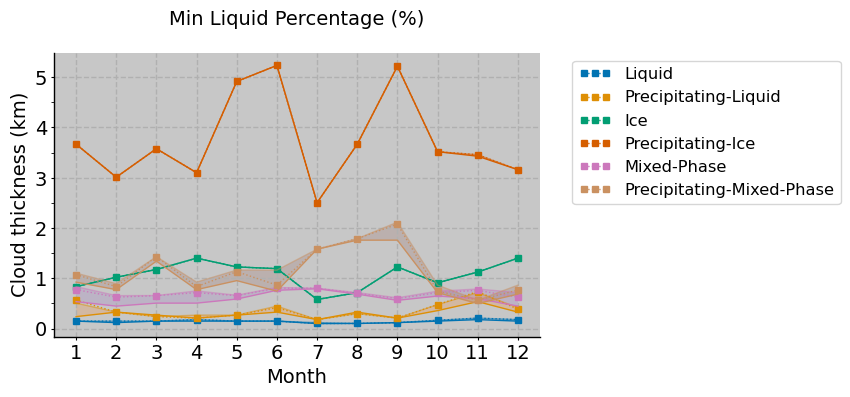

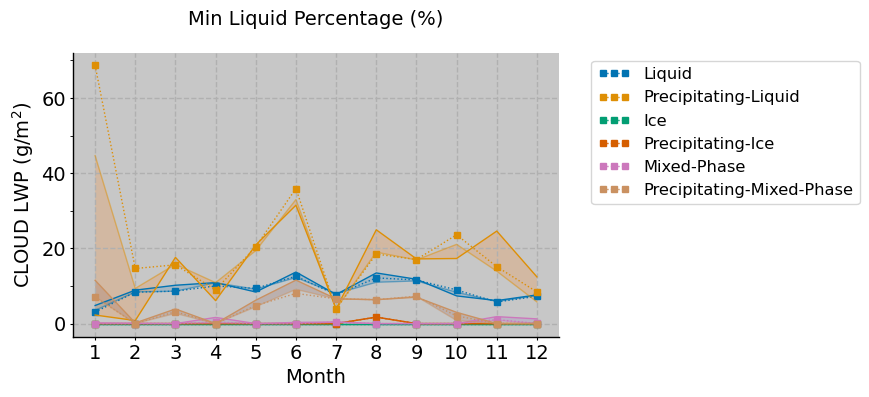

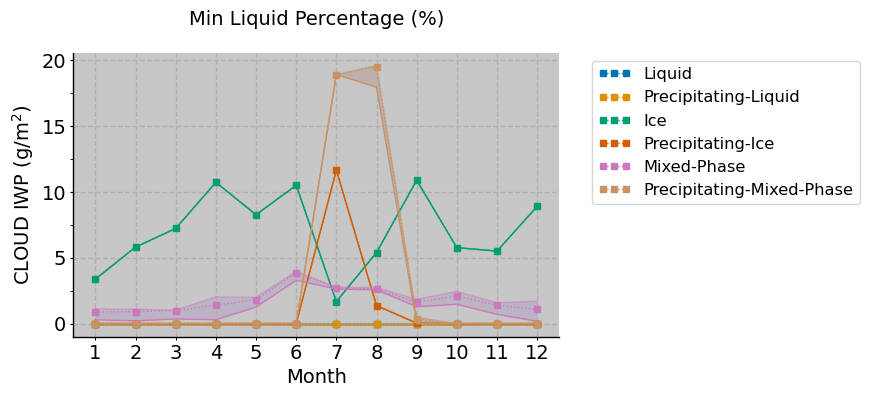

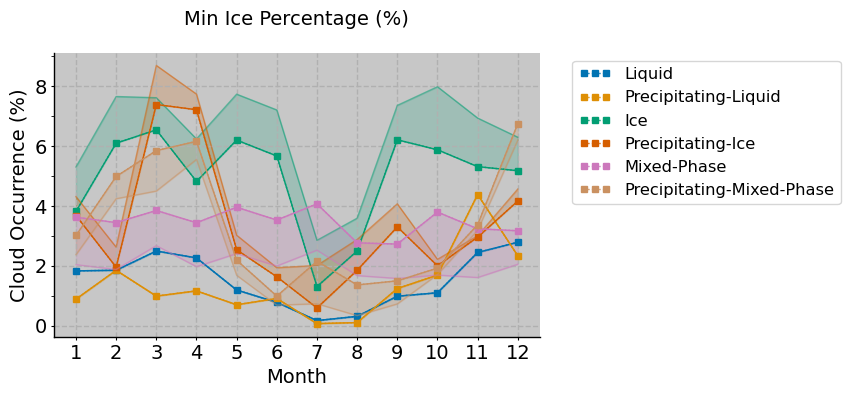

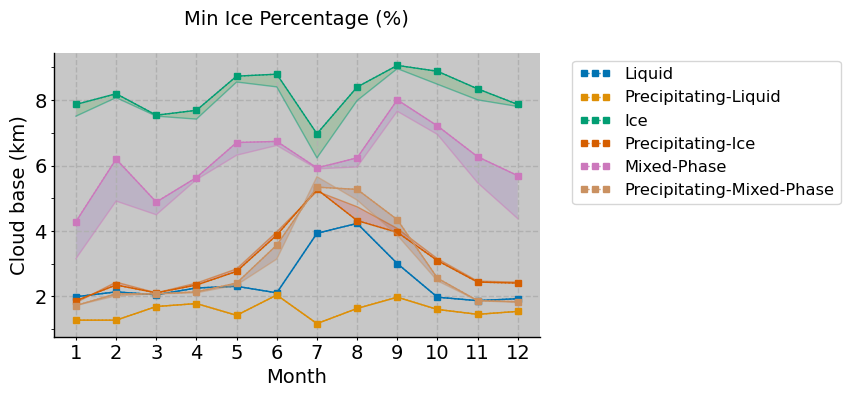

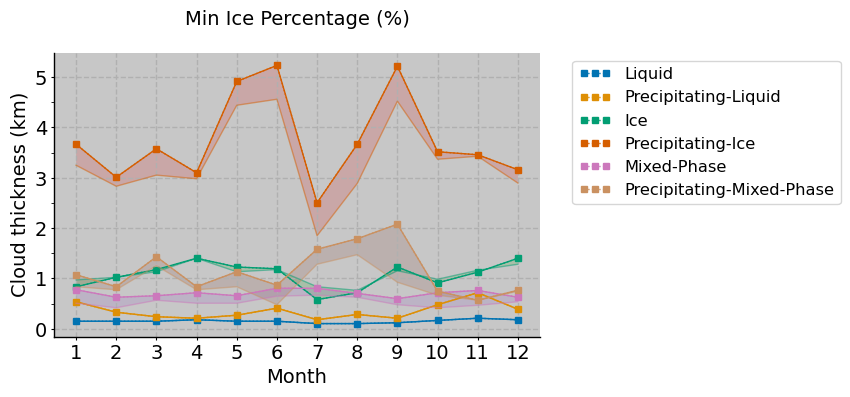

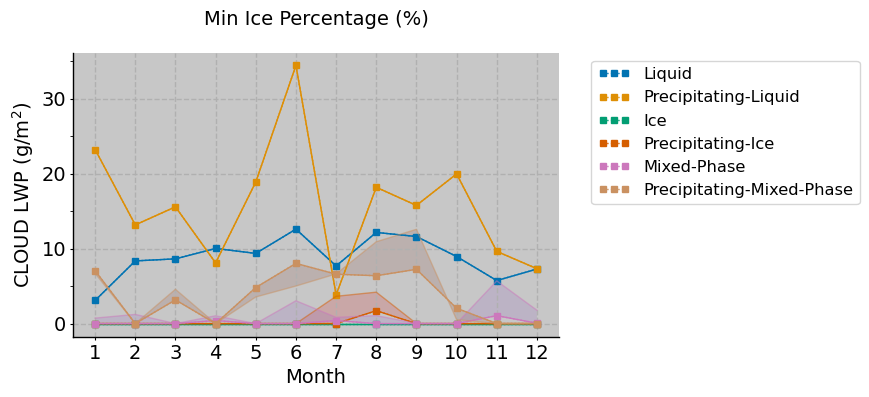

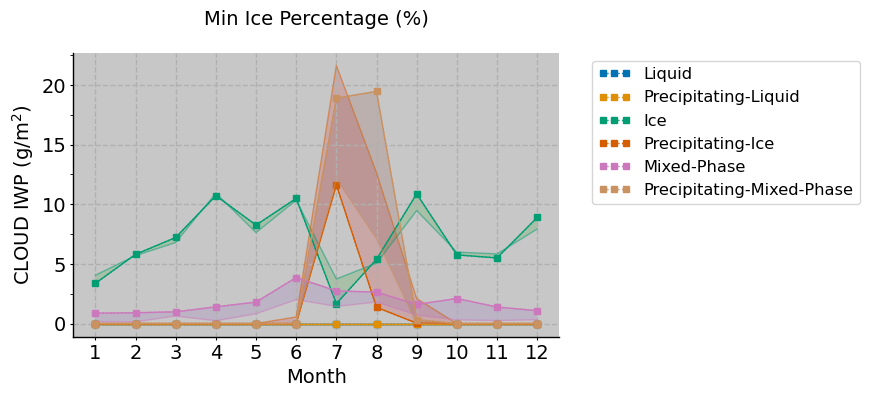

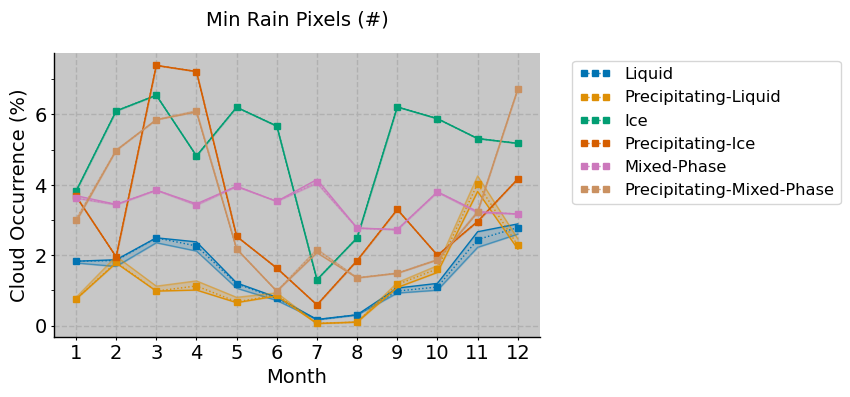

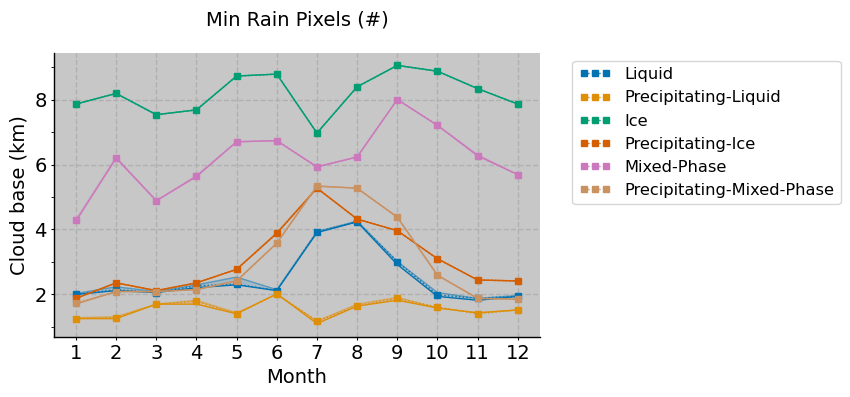

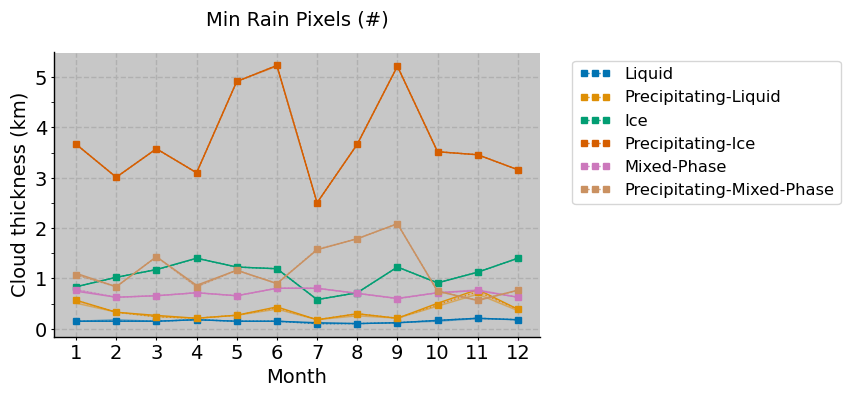

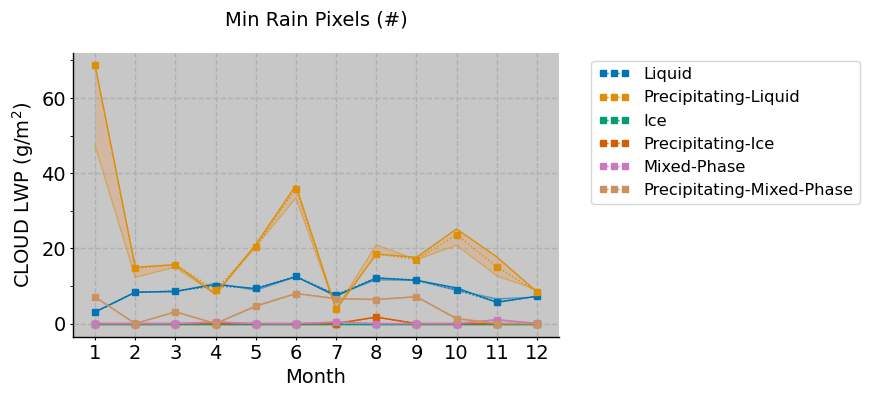

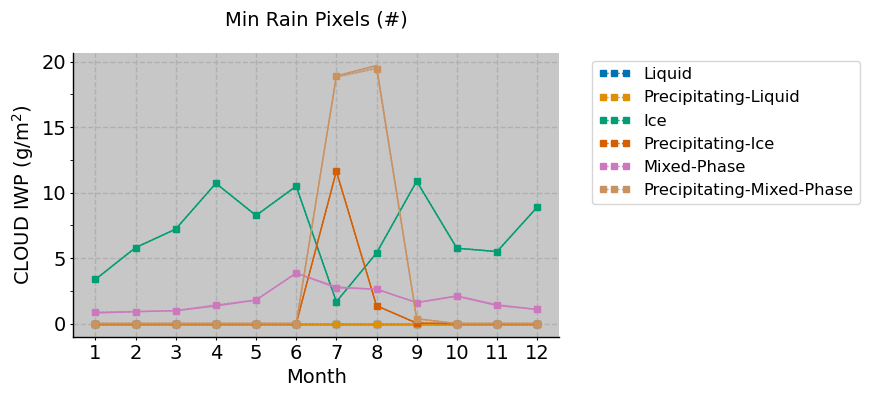

In [4]:
pattern_list = [
                "*min_cloudp.nc",
                "*min_liquid_percentage.nc",
                "*min_ice_percentage.nc",
                "*min_rainp.nc",
                ]

colors_plot = sns.color_palette("colorblind", 8)
for pattern in pattern_list:
    filenames_occurence  = glob.glob(os.path.join(filepath_cloud_occurence, pattern))
    filenames_cloud_type = glob.glob(os.path.join(filepath_cloud_cloud_type, pattern))
    filenames_properties = glob.glob(os.path.join(filepath_data, pattern))
    key = pattern[1:-3]

    # This will combine all files along the 'time' dimension by default
    ds_occ  = xr.open_mfdataset(filenames_occurence, combine='by_coords').compute()
    ds_ctp = xr.open_mfdataset(filenames_cloud_type, combine='by_coords').compute()
    ds_prop = xr.open_mfdataset(filenames_properties, combine='by_coords').compute()

    
    clouds = list(ds_ctp.data_vars)[:-1]
    parameter_names = {'min_liquid_percentage': 'Min Liquid Percentage (%)',
                    'min_ice_percentage': 'Min Ice Percentage (%)',
                    'min_cloudp': 'Min Number of Cloud Pixels (#)',
                    'min_rainp': 'Min Rain Pixels (#)'
                    }

    coordinates_to_remove = {'min_cloudp':[0, 20, 40, 160],
                        'min_liquid_percentage':[50, 55, 95, 100],
                        'min_ice_percentage': [60, 65, 70, 75],
                        'min_rainp':[0, 20],
                        }

    standard_cba_thre = {'min_cloudp':100,
                        'min_liquid_percentage':70,
                        'min_ice_percentage':90,
                        'min_rainp':10,
                        }
    # ----------------------------------------------------------------------------------------------------------------
    # First plot the occurrences
    # ----------------------------------------------------------------------------------------------------------------
    if coordinates_to_remove[key] is not None:
        for i, value in enumerate(coordinates_to_remove[key]):
            if i == 0:
                mask_coord = (ds_prop[key] != value)
            else:
                mask_coord &= (ds_prop[key] != value)

        ds_occ = ds_occ.where(mask_coord, drop=True)
        ds_ctp = ds_ctp.where(mask_coord, drop=True)
        ds_prop = ds_prop.where(mask_coord, drop=True)

    mask = (ds_occ.single_layer == 1 ) & (ds_occ.attenuation == False)
    prop    = list(ds_prop.data_vars)
    thres_v = ( ds_prop[key].min(), ds_prop[key].max() )

    fig, ax = plt.subplots(figsize=(6,4))
    for cloud in clouds:
        # ds_prop = ds_prop.where(mask_cloud & mask)
        freq_occ = ds_ctp[cloud].where(mask, 0).groupby('time.month').mean()*100

        # take the mean by month
        # min_freq = freq_occ.min(dim=key)
        # max_freq = freq_occ.max(dim=key)
        
        min_freq = freq_occ.sel(**{key:thres_v[0]})
        max_freq = freq_occ.sel(**{key:thres_v[1]})

        standard_value = standard_cba_thre[key]

        # for each cloud, plot the standar value line and error bars between lower and upper freq
        ax.plot(freq_occ.month,
                freq_occ.sel(**{key:standard_value}), 
                linestyle=':',
                marker='s',
                markersize=4,
                color = colors_plot[clouds.index(cloud)],
                label=f'{cloud}',
                )
        
        # plot the min and max freq to contextualize the variation
        # include a legend that explains the min and max lines
        ax.plot(min_freq.month, min_freq, linestyle='-', color = colors_plot[clouds.index(cloud)], alpha=0.5)
        ax.plot(max_freq.month, max_freq, linestyle='-', color = colors_plot[clouds.index(cloud)])

        ax.fill_between(freq_occ.month,
                        min_freq,
                        max_freq,
                        alpha=0.2,
                        color = colors_plot[clouds.index(cloud)],
                        )
        
    ax.set_title(f'{parameter_names[key]}')
    ax.set_xlabel('Month')
    ax.set_xticks(np.arange(1,13,1)) # add ticks in x-axis at each month
    ax.yaxis.set_minor_locator(AutoMinorLocator(2)) # add subticks in y-axis at 0.5 intervals
    ax.set_ylabel('Cloud Occurrence (%)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small') # let the legend outside the plot on right side
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

    # ----------------------------------------------------------------------------------------------------------------
    # Now plot the properties
    # ----------------------------------------------------------------------------------------------------------------

    for i, p in enumerate(prop):
        fig, ax = plt.subplots(figsize=(6,4))
        for cloud in clouds:
            mask_cloud = (ds_ctp[cloud] == 1.)
            # ds_prop = ds_prop.where(mask_cloud & mask)
            stat_ref = ds_prop[p].where(mask & mask_cloud).sel(**{key:standard_cba_thre[key]}).groupby('time.month').median()
            stat_lower = ds_prop[p].where(mask & mask_cloud).sel(**{key:thres_v[0]}).groupby('time.month').median()
            stat_upper = ds_prop[p].where(mask & mask_cloud).sel(**{key:thres_v[1]}).groupby('time.month').median()

            if p == 'cloud_lwp' or p == 'cloud_iwp':
                stat_ref = stat_ref*1000
                stat_lower = stat_lower*1000
                stat_upper = stat_upper*1000
                # let all CAPITAL
                ax.set_ylabel(p.replace('_', ' ').upper() + r' (g/m$^2$)')
            else:
                stat_ref = stat_ref/1000
                stat_lower = stat_lower/1000
                stat_upper = stat_upper/1000
                ax.set_ylabel(p.replace('_', ' ').capitalize() + ' (km)')
            
            ax.plot(stat_ref.month,
                    stat_ref,
                    linestyle=':',
                    marker='s',
                    markersize=4,
                    color = colors_plot[clouds.index(cloud)],
                    label=f'{cloud}',
                    )
            
            # plot the min and max freq to contextualize the variation
            ax.plot(stat_lower.month, stat_lower, linestyle='-', color = colors_plot[clouds.index(cloud)], alpha=0.5)
            ax.plot(stat_upper.month, stat_upper, linestyle='-', color = colors_plot[clouds.index(cloud)])

            ax.fill_between(stat_ref.month,
                            stat_lower,
                            stat_upper,
                            alpha=0.2,
                            )
            
        ax.set_title(f'{parameter_names[key]}')
        ax.set_xlabel('Month')
        ax.set_xticks(np.arange(1,13,1))
        # if i == 0:
        #     ax.legend( bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        # else:
        #     ax.legend().set_visible(False)
        ax.legend( bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        
        fig.savefig(os.path.join(figure_path, f'cloud_properties_{p}_{key}_sensitivity_analysis.png'), dpi=300, bbox_inches='tight')
        plt.show()

# Comparison between CBA and PBA: over-uniformity

### Reading PBA outputs

In [6]:
# -----------------------------------------------------------------------
# Old Method of cloud classification 
# -----------------------------------------------------------------------
# " DASK: >=2022.7.1,<2023.0.0"
root_folder = '/home/matheustolen/Documentos/matheus_doctorado/profile-based-processing/'
target_parent_folder = "number_of_layers"
# chirp_lwp = reading_dataset_chunking(root_folder, target_parent_folder)
print("Reading the netCDF files into a list of xarray datasets of old method...")
chirp_layers = reading_dataset_chunking(root_folder, target_parent_folder)

layer_list   = [ds for ds in chirp_layers.values()]
cloud_layers = xr.concat(layer_list, dim='time').sortby('time')

df_layers     = cloud_layers.to_dataframe()
mask_single   = (df_layers.sum(axis=1) == 1.0).to_numpy() # Mask with single layer for any kind of cloud
mask_multi    = (df_layers.sum(axis=1) > 1.0) # Mask with multi layer clouds
mask_w_clouds = (df_layers.sum(axis=1) == 0.0) # Mask with no clouds
del df_layers
#-------------------------------------------------------------------------------------------------
# NOTE: New variable is a mask, keep this sequence to avoid integer greater thabn 1
#-------------------------------------------------------------------------------------------------
ds_occ_pba = cloud_layers.where(mask_single, other=0.0)
ds_occ_pba['no_clouds']  = xr.DataArray(mask_w_clouds.astype(np.float64), dims='time')
ds_occ_pba['multilayer'] = xr.DataArray(mask_multi.astype(np.float64), dims='time')
# fill nan values with 0
ds_occ_pba = ds_occ_pba.fillna(0.0) # fill no single layer clouds by zero values
ds_occ_pba = ds_occ_pba.assign_coords(years=ds_occ_pba['time'].dt.year,
                                                            month=ds_occ_pba['time'].dt.month
                                                            ).compute()
print("End of reading the netCDF files into a list of xarray datasets...")

if 'Pre_liquid' in ds_occ_pba.data_vars:
    ds_occ_pba = ds_occ_pba.rename({'Pre_liquid': 'Precipitating-Liquid',
                                                        'Mixed_phase': 'Mixed-Phase',
                                                        'Pre_mixed_phase': 'Precipitating-Mixed-Phase'})
    ds_occ_pba = ds_occ_pba.drop_vars(['no_clouds', 'multilayer'])

Reading the netCDF files into a list of xarray datasets of old method...
End of reading the netCDF files into a list of xarray datasets...


In [53]:
ds_occ_pba.head

<bound method Dataset.head of <xarray.Dataset>
Dimensions:                    (time: 3976104)
Coordinates:
  * time                       (time) datetime64[ns] 2018-04-23T15:28:45 ... ...
    years                      (time) int64 2018 2018 2018 ... 2023 2023 2023
    month                      (time) int64 4 4 4 4 4 4 4 ... 12 12 12 12 12 12
Data variables:
    Liquid                     (time) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Ice                        (time) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Mixed-Phase                (time) float64 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0
    Precipitating-Liquid       (time) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Precipitating-Mixed-Phase  (time) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0>

In [7]:
standard_cba_thre = {'min_cloudp':100,
                    'min_liquid_percentage':70,
                    'min_ice_percentage':90,
                    'min_rainp':10,
                    }

pattern = "*min_rainp.nc"
filenames_occurence  = glob.glob(os.path.join(filepath_cloud_occurence, pattern))
filenames_cloud_type = glob.glob(os.path.join(filepath_cloud_cloud_type, pattern))
filenames_properties = glob.glob(os.path.join(filepath_data, pattern))

key = pattern[1:-3]
# This will combine all files along the 'time' dimension by default
ds_occ_cba = xr.open_mfdataset(filenames_occurence, combine='by_coords').sel(**{key: standard_cba_thre[key]}).compute()
ds_ctp_cba = xr.open_mfdataset(filenames_cloud_type, combine='by_coords').sel(**{key: standard_cba_thre[key]}).compute()
ds_prop = xr.open_mfdataset(filenames_properties, combine='by_coords').sel(**{key: standard_cba_thre[key]}).compute()

In [7]:
ds_prop.head

<bound method Dataset.head of <xarray.Dataset>
Dimensions:          (time: 3976104)
Coordinates:
  * time             (time) datetime64[ns] 2018-04-23T15:28:45.001144409 ... ...
    min_rainp        int64 10
Data variables:
    cloud_base       (time) float64 4.474e+03 4.407e+03 ... 5.372e+03 5.372e+03
    cloud_thickness  (time) float64 1.298e+03 1.364e+03 ... 5.665e+03 5.665e+03
    cloud_lwp        (time) float64 0.0 0.0 0.0 ... 0.003444 0.003203 0.00104
    cloud_iwp        (time) float64 0.02524 0.01677 0.01001 ... 0.1925 0.1928>

In [8]:
mask = (ds_occ_cba.single_layer == 1 ) & (ds_occ_cba.attenuation == False)
ds_prop_cba_single_layer = ds_prop.where(mask)
ds_occ_cba_single_layer = ds_occ_cba.where(mask, 0)
ds_ctp_cba_single_layer = ds_ctp_cba.where(mask, 0)
ds_prop_cba_single_layer.head

<bound method Dataset.head of <xarray.Dataset>
Dimensions:          (time: 3976104)
Coordinates:
  * time             (time) datetime64[ns] 2018-04-23T15:28:45.001144409 ... ...
    min_rainp        int64 10
Data variables:
    cloud_base       (time) float64 4.474e+03 4.407e+03 ... 5.372e+03 5.372e+03
    cloud_thickness  (time) float64 1.298e+03 1.364e+03 ... 5.665e+03 5.665e+03
    cloud_lwp        (time) float64 0.0 0.0 0.0 ... 0.003444 0.003203 0.00104
    cloud_iwp        (time) float64 0.02524 0.01677 0.01001 ... 0.1925 0.1928>

In [9]:
props = list(ds_prop_cba_single_layer.data_vars)
cloud = 'Mixed-Phase'
for p in props:
    # plot a comparison between PBA and CBA methods for each property p
    ds_stat_cba = ds_prop_cba_single_layer.where(ds_ctp_cba[cloud])[p].resample(time='M').median()
    ds_stat_cba_q25 = ds_prop_cba_single_layer.where(ds_ctp_cba[cloud])[p].resample(time='M').quantile(0.25)
    ds_stat_cba_q75 = ds_prop_cba_single_layer.where(ds_ctp_cba[cloud])[p].resample(time='M').quantile(0.75)
    ds_stat_pba = ds_prop.where(ds_occ_pba[cloud])[p].resample(time='M').median()
    ds_stat_pba_q25 = ds_prop.where(ds_occ_pba[cloud])[p].resample(time='M').quantile(0.25)
    ds_stat_pba_q75 = ds_prop.where(ds_occ_pba[cloud])[p].resample(time='M').quantile(0.75)

    fig, ax = plt.subplots(figsize=(10,5))

    if p == 'cloud_lwp' or p == 'cloud_iwp':
        ds_stat_cba = ds_stat_cba*1000
        ds_stat_cba_q25 = ds_stat_cba_q25*1000
        ds_stat_cba_q75 = ds_stat_cba_q75*1000
        ds_stat_pba = ds_stat_pba*1000
        ds_stat_pba_q25 = ds_stat_pba_q25*1000
        ds_stat_pba_q75 = ds_stat_pba_q75*1000
        ax.set_ylabel(p.replace('_', ' ').upper() + r' (g/m$^2$)')
    else:
        ds_stat_cba = ds_stat_cba/1000
        ds_stat_cba_q25 = ds_stat_cba_q25/1000
        ds_stat_cba_q75 = ds_stat_cba_q75/1000
        ds_stat_pba = ds_stat_pba/1000
        ds_stat_pba_q25 = ds_stat_pba_q25/1000
        ds_stat_pba_q75 = ds_stat_pba_q75/1000
        ax.set_ylabel(p.replace('_', ' ').capitalize() + ' (km)')
    
    ax.plot(ds_stat_cba['time'], ds_stat_cba, label='CBA Method', color='blue', marker='s', linestyle='-')
    ax.fill_between(ds_stat_cba['time'],
                    ds_stat_cba_q25,
                    ds_stat_cba_q75,
                    color='blue', alpha=0.2)
    ax.plot(ds_stat_pba['time'], ds_stat_pba, label='PBA Method', color='orange', marker='o', linestyle='--')
    ax.fill_between(ds_stat_pba['time'],
                    ds_stat_pba_q25,
                    ds_stat_pba_q75,
                    color='orange', alpha=0.2)  

    ax.set_title(f'Comparison of Cloud Property: {p.replace("_", " ").capitalize()} for {cloud} Clouds')
    ax.set_xlabel('Time')

    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.savefig(os.path.join(figure_path, f'comparison_{p}_{cloud}_CBA_PBA.png'), dpi=300, bbox_inches='tight')
    plt.show()


/home/matheustolen/Documentos/matheus_doctorado/repositories/cloud-statistics/.venv/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,
/home/matheustolen/Documentos/matheus_doctorado/repositories/cloud-statistics/.venv/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,
/home/matheustolen/Documentos/matheus_doctorado/repositories/cloud-statistics/.venv/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,
/home/matheustolen/Documentos/matheus_doctorado/repositories/cloud-statistics/.venv/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,
/tmp/ipykernel_1684655/1123971337.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be sho

In [77]:
cba_cloud_thickness = ds_prop_cba_single_layer.where(ds_ctp_cba['Mixed-Phase'])['cloud_thickness'].resample(time='D').median()
pba_cloud_thickness = ds_prop.where(ds_occ_pba['Mixed-Phase'])['cloud_thickness'].resample(time='D').median()

diff_methods_thickness = cba_cloud_thickness - pba_cloud_thickness
mask_large_diff = np.abs(diff_methods_thickness) > 1000  # 1 km threshold

In [83]:
diff_methods_thickness[mask_large_diff].time

<xarray.DataArray 'time' (time: 188)>
array(['2018-07-19T00:00:00.000000000', '2018-08-16T00:00:00.000000000',
       '2018-08-27T00:00:00.000000000', '2018-08-30T00:00:00.000000000',
       '2018-09-11T00:00:00.000000000', '2018-09-14T00:00:00.000000000',
       '2018-09-26T00:00:00.000000000', '2018-10-01T00:00:00.000000000',
       '2018-10-09T00:00:00.000000000', '2018-10-21T00:00:00.000000000',
       '2019-05-02T00:00:00.000000000', '2019-05-18T00:00:00.000000000',
       '2019-05-19T00:00:00.000000000', '2019-05-21T00:00:00.000000000',
       '2019-05-24T00:00:00.000000000', '2019-06-03T00:00:00.000000000',
       '2019-06-05T00:00:00.000000000', '2019-06-14T00:00:00.000000000',
       '2019-06-27T00:00:00.000000000', '2019-09-13T00:00:00.000000000',
       '2019-09-17T00:00:00.000000000', '2019-09-19T00:00:00.000000000',
       '2019-09-20T00:00:00.000000000', '2019-09-21T00:00:00.000000000',
       '2019-09-30T00:00:00.000000000', '2019-10-19T00:00:00.000000000',
       '2019-10-22T00:00:00.000000000', '2019-10-30T00:00:00.000000000',
       '2019-11-10T00:00:00.000000000', '2019-12-16T00:00:00.000000000',
       '2019-12-17T00:00:00.000000000', '2019-12-19T00:00:00.000000000',
       '2019-12-26T00:00:00.000000000', '2019-12-27T00:00:00.000000000',
       '2020-01-03T00:00:00.000000000', '2020-01-13T00:00:00.000000000',
       '2020-01-14T00:00:00.000000000', '2020-01-15T00:00:00.000000000',
       '2020-01-17T00:00:00.000000000', '2020-01-18T00:00:00.000000000',
       '2020-01-24T00:00:00.000000000', '2020-01-30T00:00:00.000000000',
       '2020-02-07T00:00:00.000000000', '2020-02-28T00:00:00.000000000',
       '2020-03-13T00:00:00.000000000', '2020-03-14T00:00:00.000000000',
       '2020-03-21T00:00:00.000000000', '2020-04-05T00:00:00.000000000',
       '2020-04-12T00:00:00.000000000', '2020-04-21T00:00:00.000000000',
       '2020-04-27T00:00:00.000000000', '2020-04-28T00:00:00.000000000',
       '2020-05-02T00:00:00.000000000', '2020-05-07T00:00:00.000000000',
       '2020-05-08T00:00:00.000000000', '2020-05-11T00:00:00.000000000',
       '2020-05-16T00:00:00.000000000', '2020-05-31T00:00:00.000000000',
       '2020-06-14T00:00:00.000000000', '2020-07-21T00:00:00.000000000',
       '2020-08-01T00:00:00.000000000', '2020-09-01T00:00:00.000000000',
       '2020-09-13T00:00:00.000000000', '2020-09-14T00:00:00.000000000',
       '2020-09-16T00:00:00.000000000', '2020-09-18T00:00:00.000000000',
       '2020-09-20T00:00:00.000000000', '2020-09-21T00:00:00.000000000',
       '2020-09-23T00:00:00.000000000', '2020-10-02T00:00:00.000000000',
       '2020-10-09T00:00:00.000000000', '2020-10-22T00:00:00.000000000',
       '2020-11-05T00:00:00.000000000', '2020-11-06T00:00:00.000000000',
       '2020-12-01T00:00:00.000000000', '2020-12-14T00:00:00.000000000',
       '2020-12-16T00:00:00.000000000', '2020-12-25T00:00:00.000000000',
       '2021-01-10T00:00:00.000000000', '2021-02-05T00:00:00.000000000',
       '2021-02-25T00:00:00.000000000', '2021-03-01T00:00:00.000000000',
       '2021-03-07T00:00:00.000000000', '2021-03-19T00:00:00.000000000',
       '2021-03-26T00:00:00.000000000', '2021-03-29T00:00:00.000000000',
       '2021-04-04T00:00:00.000000000', '2021-04-08T00:00:00.000000000',
       '2021-04-09T00:00:00.000000000', '2021-04-13T00:00:00.000000000',
       '2021-04-16T00:00:00.000000000', '2021-04-21T00:00:00.000000000',
       '2021-04-26T00:00:00.000000000', '2021-04-28T00:00:00.000000000',
       '2021-05-22T00:00:00.000000000', '2021-05-27T00:00:00.000000000',
       '2021-05-29T00:00:00.000000000', '2021-05-30T00:00:00.000000000',
       '2021-06-05T00:00:00.000000000', '2021-06-08T00:00:00.000000000',
       '2021-06-12T00:00:00.000000000', '2021-06-15T00:00:00.000000000',
       '2021-06-18T00:00:00.000000000', '2021-06-19T00:00:00.000000000',
       '2021-07-25T00:00:00.000000000', '2021-08-04T00:00:00.000000000',
       '2021-08-11T00:00:00.000000000', '2021-08-22T00:00:00.000000000',
       '2021-09-06T0

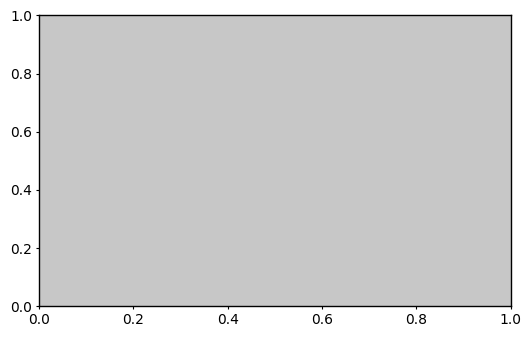

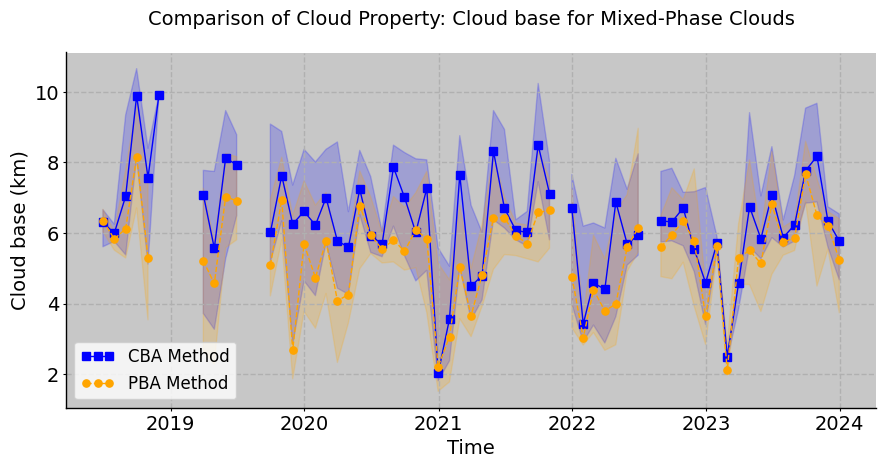

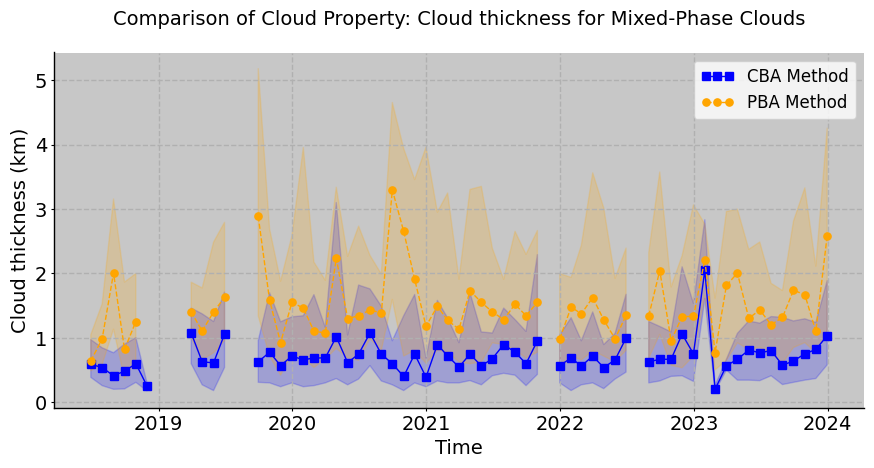

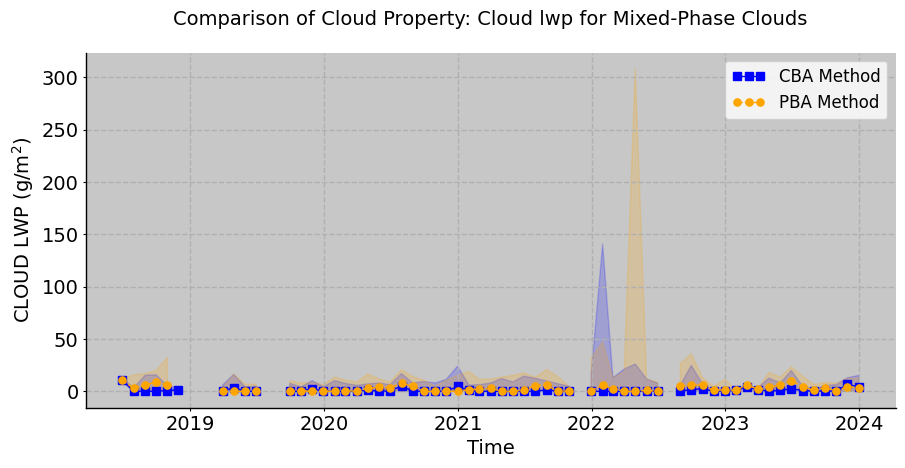

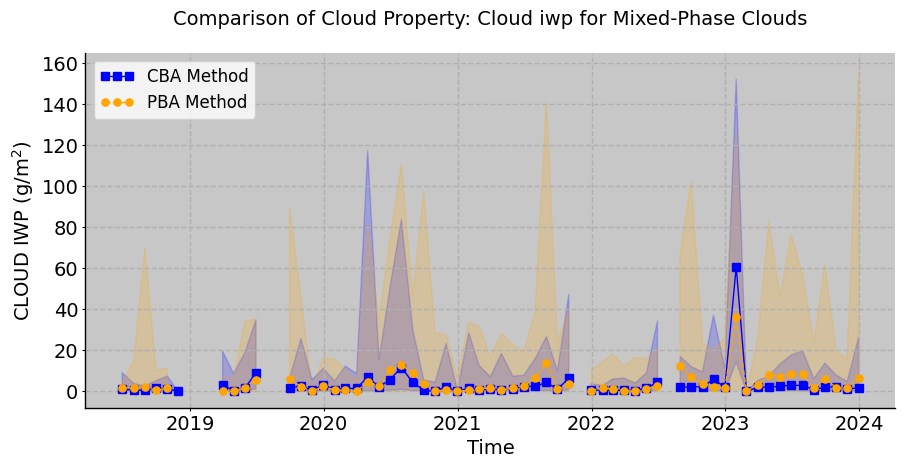

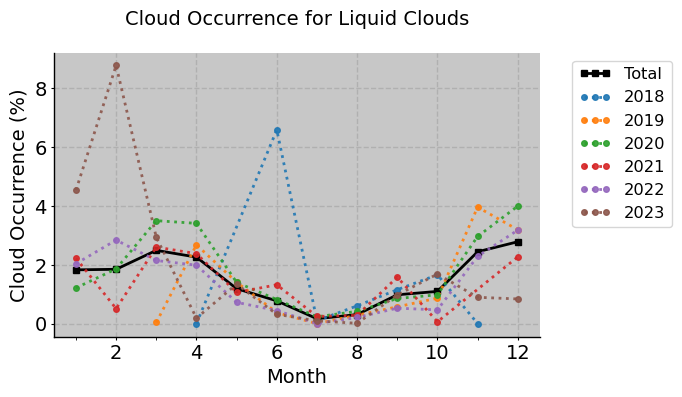

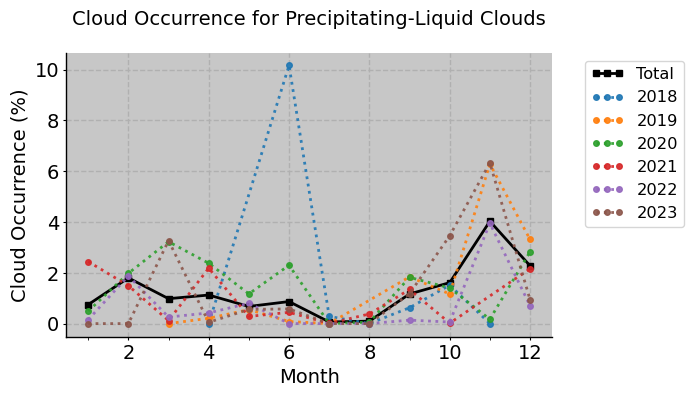

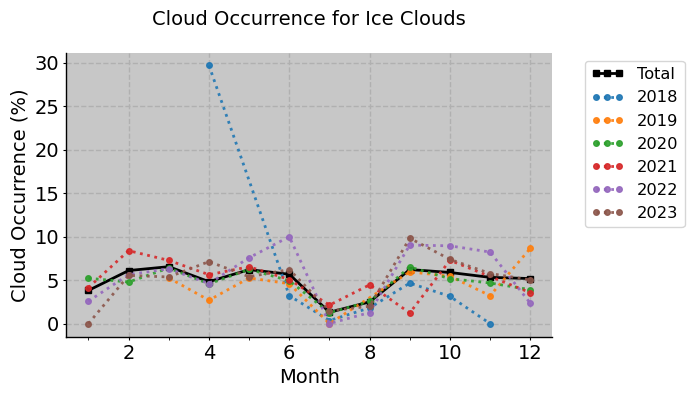

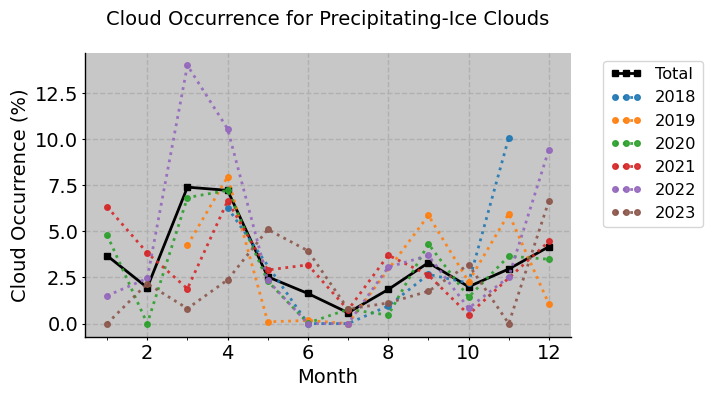

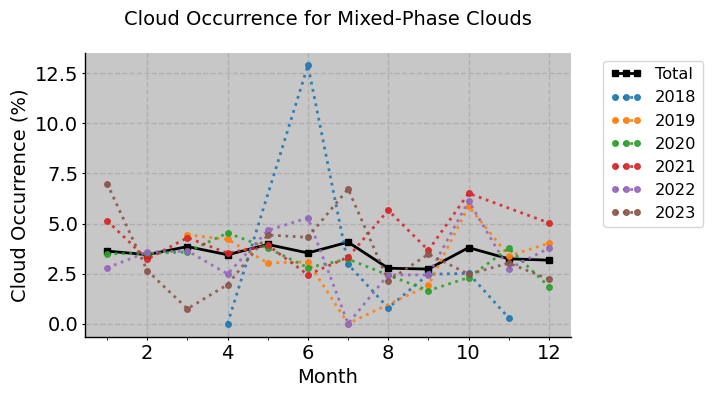

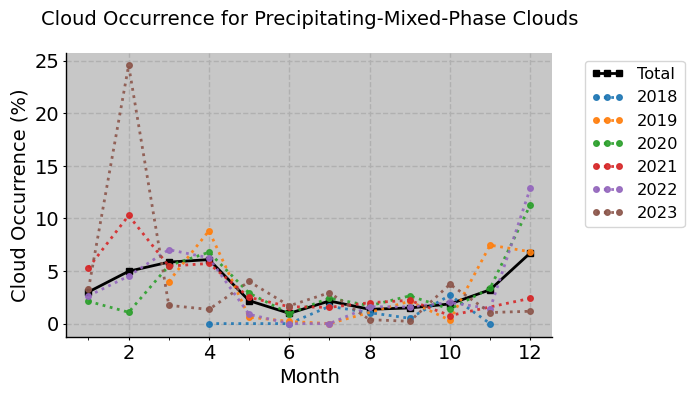

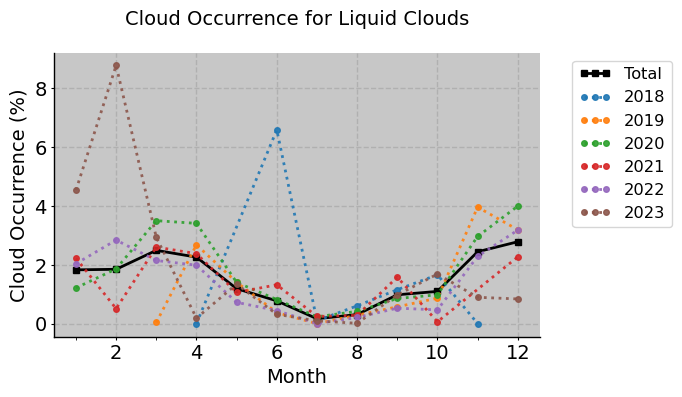

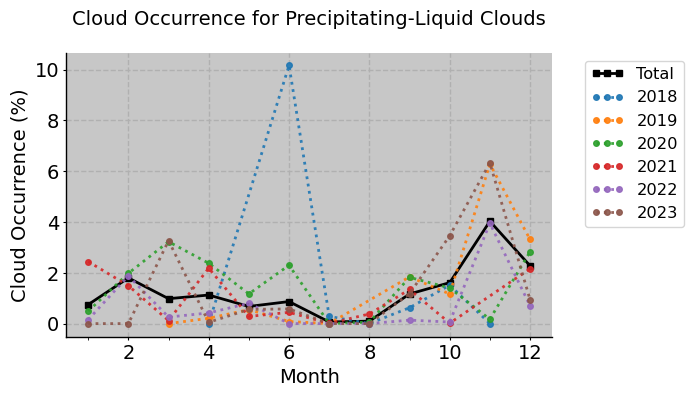

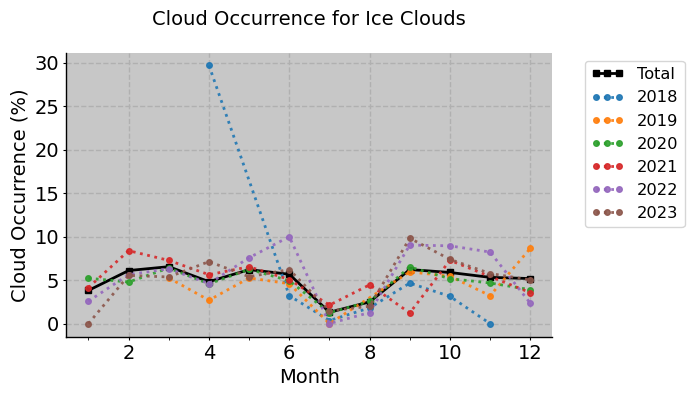

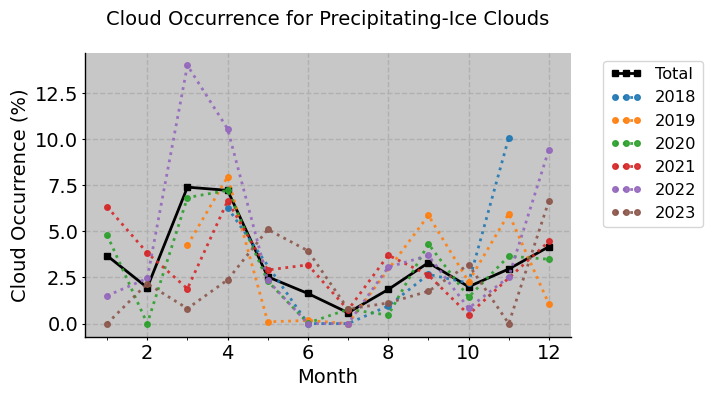

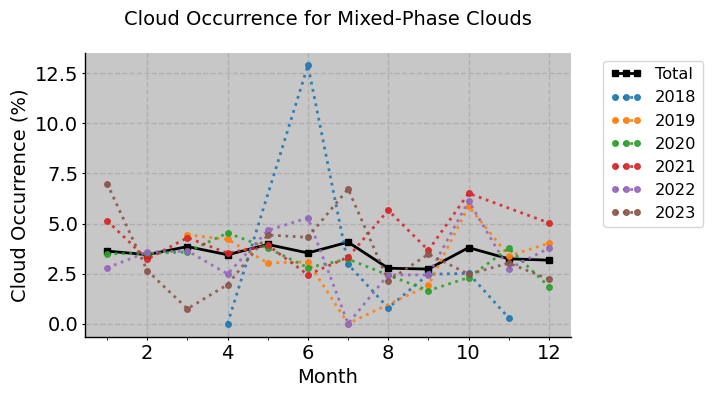

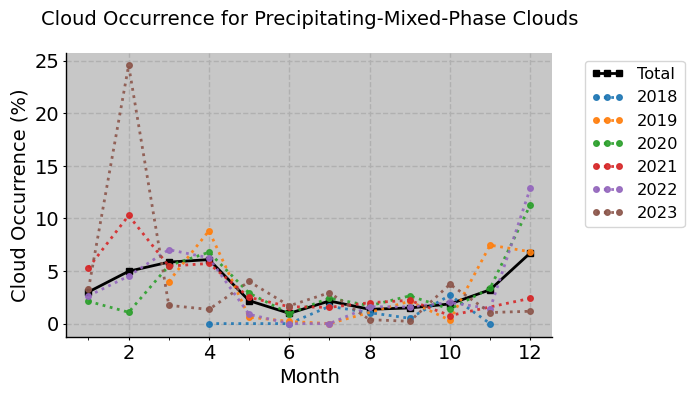

In [12]:
ds_occ_cba_single_layer

props = list(ds_prop_cba_single_layer.data_vars)
clouds = list(ds_ctp_cba.data_vars)[:-1]
years = np.unique(ds_prop['time'].dt.year)

for cloud in clouds:
    fig, ax = plt.subplots(figsize=(6,4))
    
    freq_occ_tot = ds_ctp_cba_single_layer[cloud].groupby('time.month').mean()*100
    ax.plot(freq_occ_tot['month'], 
                freq_occ_tot, 
                label='Total', 
                marker='s',
                markersize=4, 
                color = 'black', 
                linestyle='-',
                linewidth=2)
    for y in years:
        # plot a comparison between PBA and CBA methods for each property p
        freq_occ = ds_ctp_cba_single_layer[cloud].sel(time=str(y)).groupby('time.month').mean()*100
        # freq_occ = ds_ctp_cba_single_layer[cloud].sel(time=str(y)).resample(time='1M').mean()*100

        ax.plot(freq_occ['month'], 
                freq_occ, 
                label=f'{y}', 
                marker='o',
                markersize=4, 
                linestyle=':',
                linewidth=2,
                alpha=0.9,
                ) 
    ax.set_title(f'Cloud Occurrence for {cloud} Clouds')
    ax.set_xlabel('Month')
    ax.set_ylabel('Cloud Occurrence (%)')
    # let legend outside the plot on right side
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    # add more tickers on x-axis
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True) 
    fig.savefig(os.path.join(figure_path, f'cloud_occurrence_{cloud}_CBA_by_years.png'), dpi=300, bbox_inches='tight')
    plt.show()

    
    


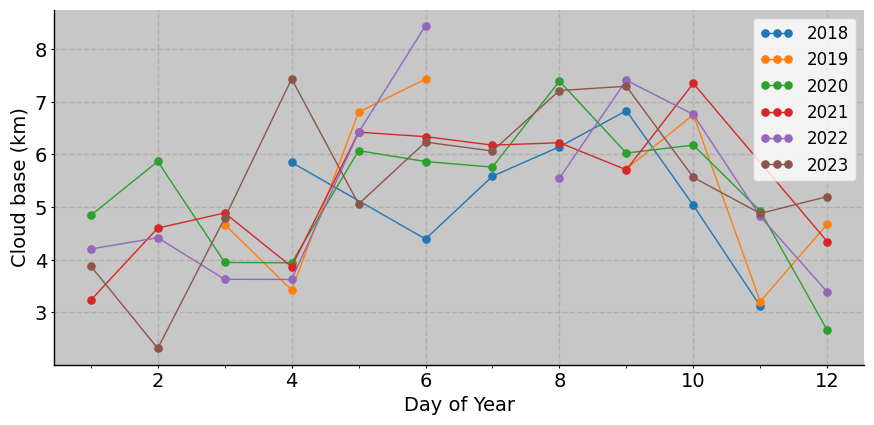

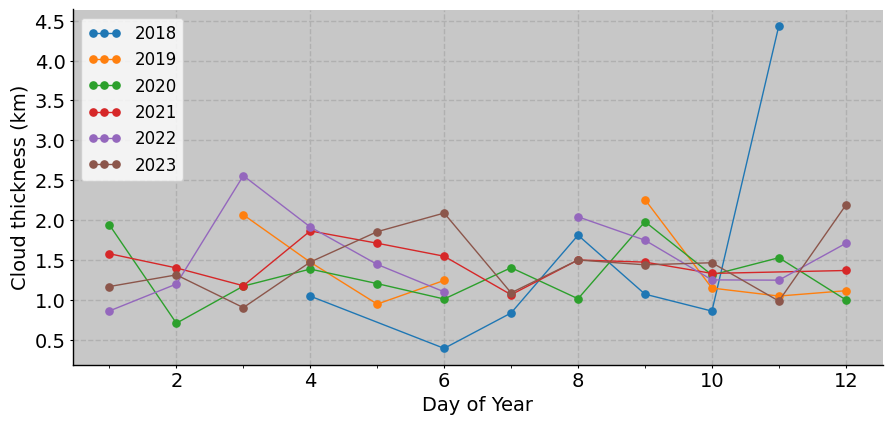

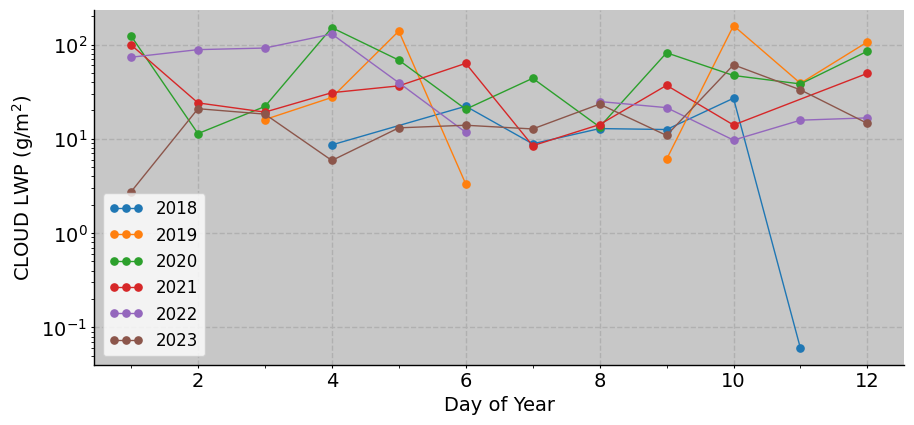

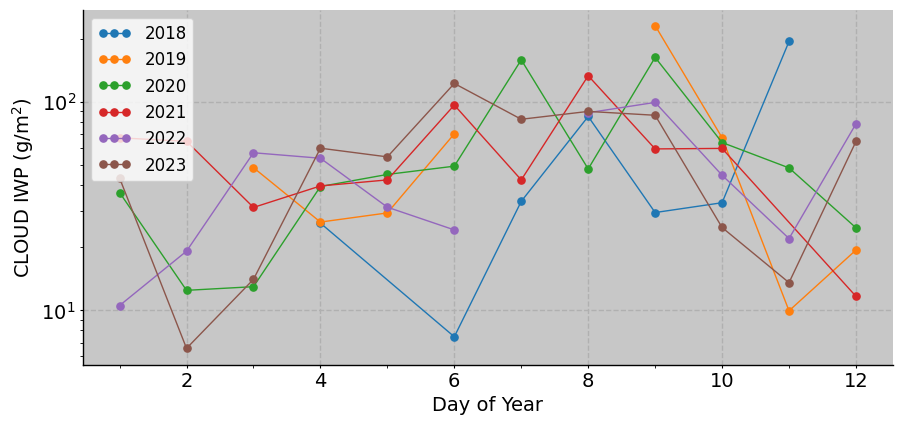

In [100]:
props = list(ds_prop_cba_single_layer.data_vars)
cloud = 'Ice'
years = np.unique(ds_prop['time'].dt.year)
for p in props:
    fig, ax = plt.subplots(figsize=(10,5))
    for y in years:
        # plot a comparison between PBA and CBA methods for each property p
        ds_stat_cba = ds_prop_cba_single_layer[p].sel(time=str(y)).groupby('time.month').mean()
        ds_stat_cba_std = ds_prop_cba_single_layer[p].sel(time=str(y)).groupby('time.month').std()

        if p == 'cloud_lwp' or p == 'cloud_iwp':
            ds_stat_cba = ds_stat_cba*1000
            ds_stat_cba_std = ds_stat_cba_std*1000
            # logscale
            ax.set_yscale('log')
            ax.set_ylabel(p.replace('_', ' ').upper() + r' (g/m$^2$)')
        else:
            ds_stat_cba = ds_stat_cba/1000
            ds_stat_cba_std = ds_stat_cba_std/1000
            ax.set_ylabel(p.replace('_', ' ').capitalize() + ' (km)')
        
        ax.plot(ds_stat_cba['month'], 
                ds_stat_cba, 
                label=f'{y}', 
                marker='o', 
                linestyle='-')
        # ax.fill_between(ds_stat_cba['month'],
        #                 ds_stat_cba - ds_stat_cba_std,
        #                 ds_stat_cba + ds_stat_cba_std, 
        #                 alpha=0.2)
        
    ax.set_xlabel('Day of Year')
    ax.legend()
    # add more tickers on x-axis
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True)
    plt.show()  



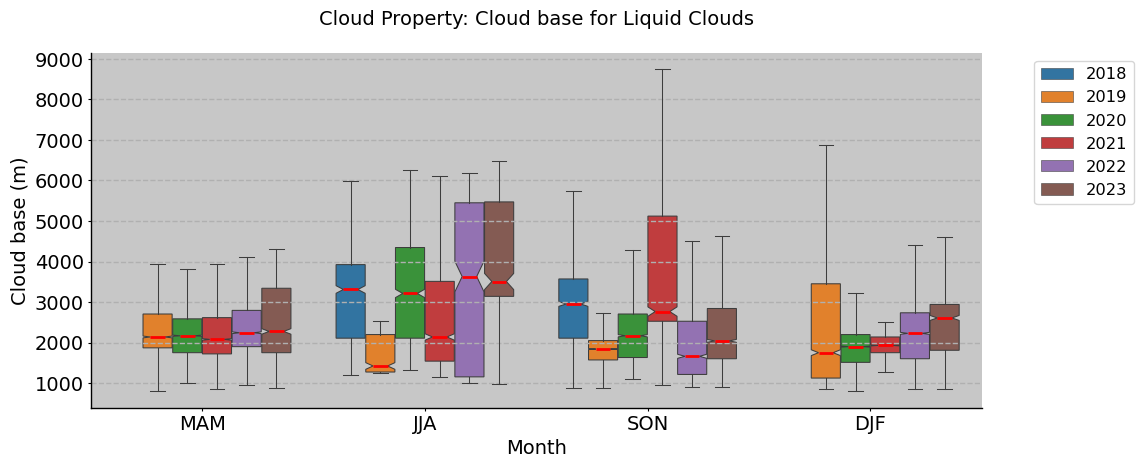

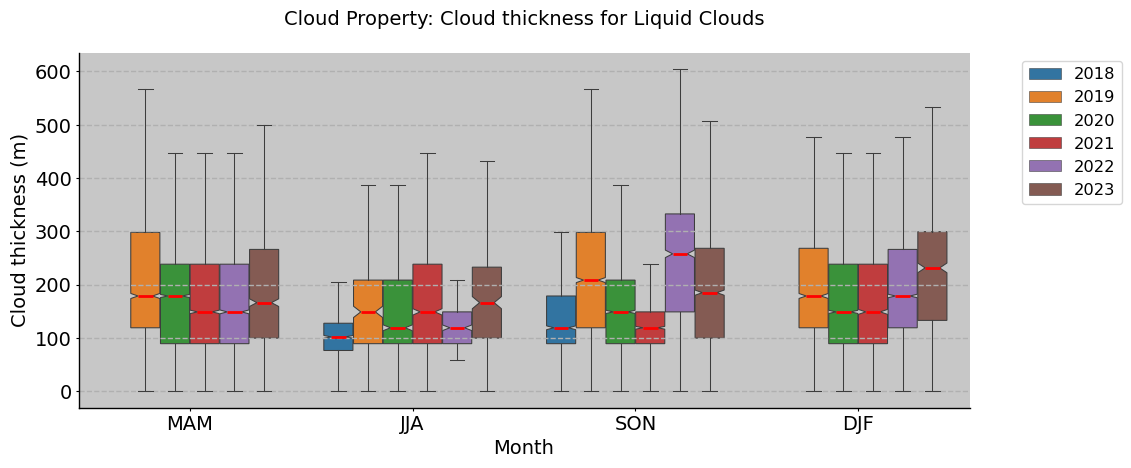

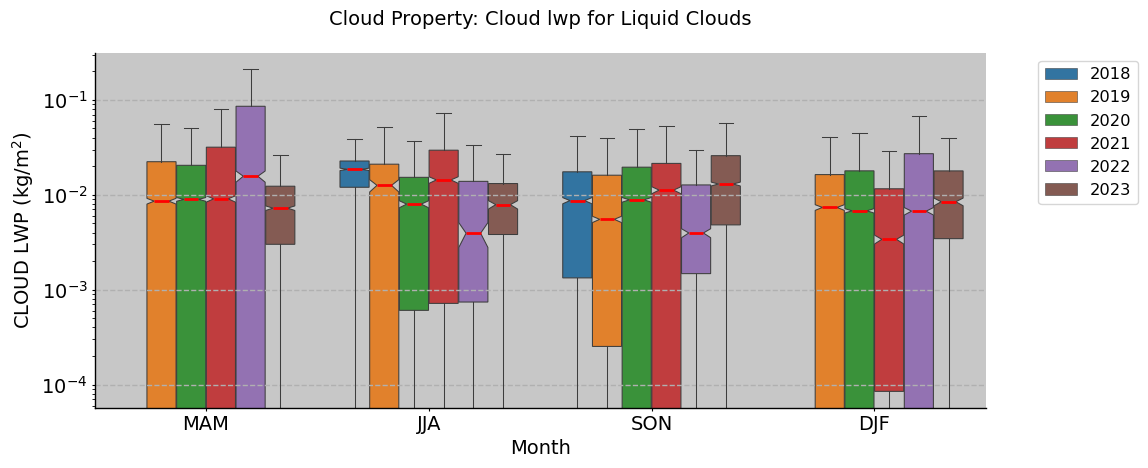

/tmp/ipykernel_872186/7138113.py:30: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


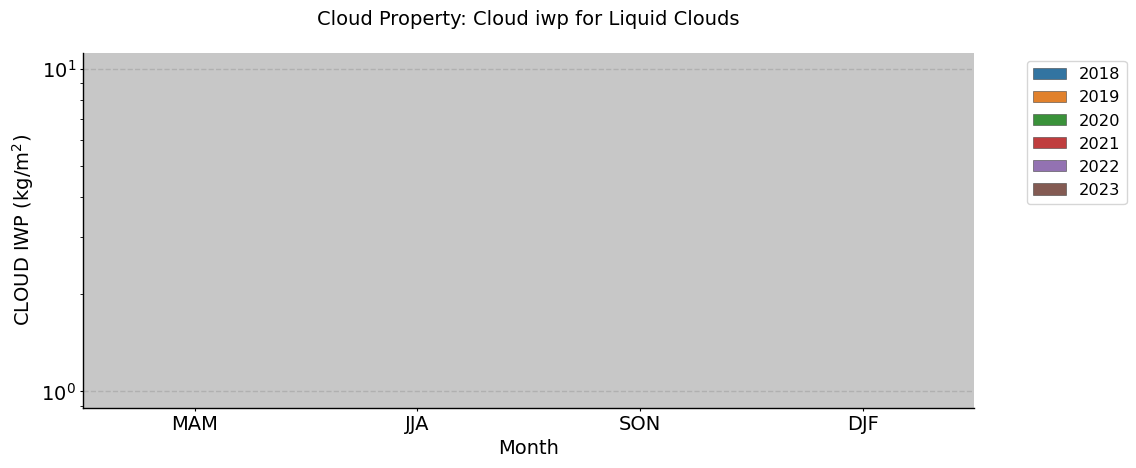

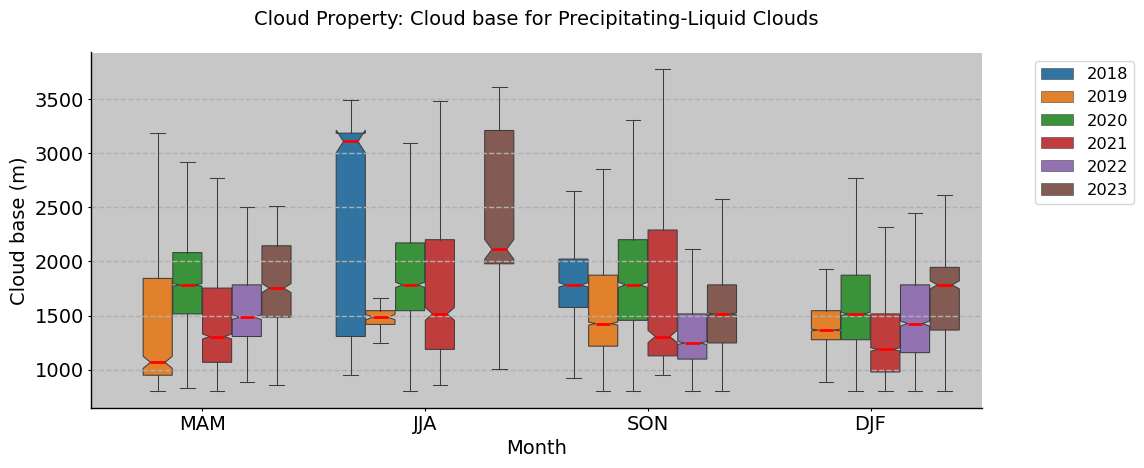

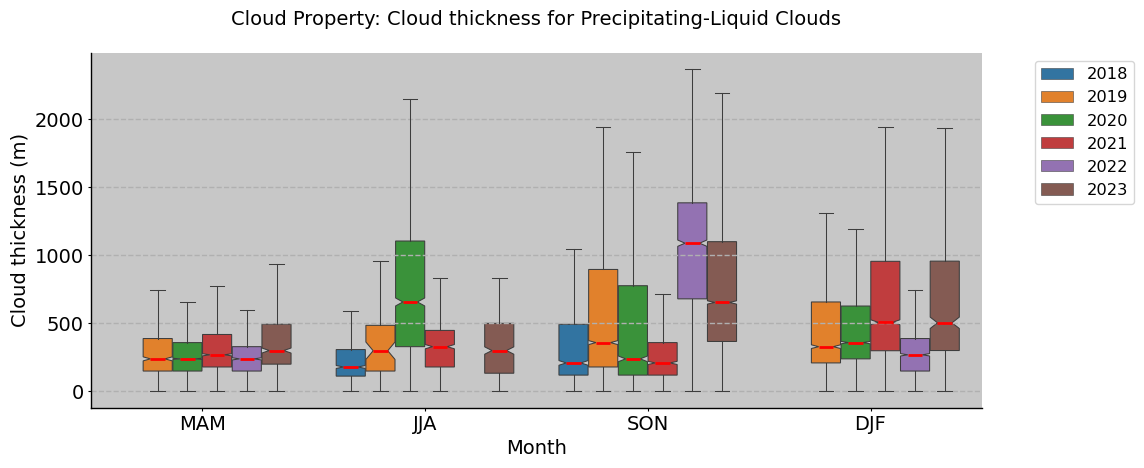

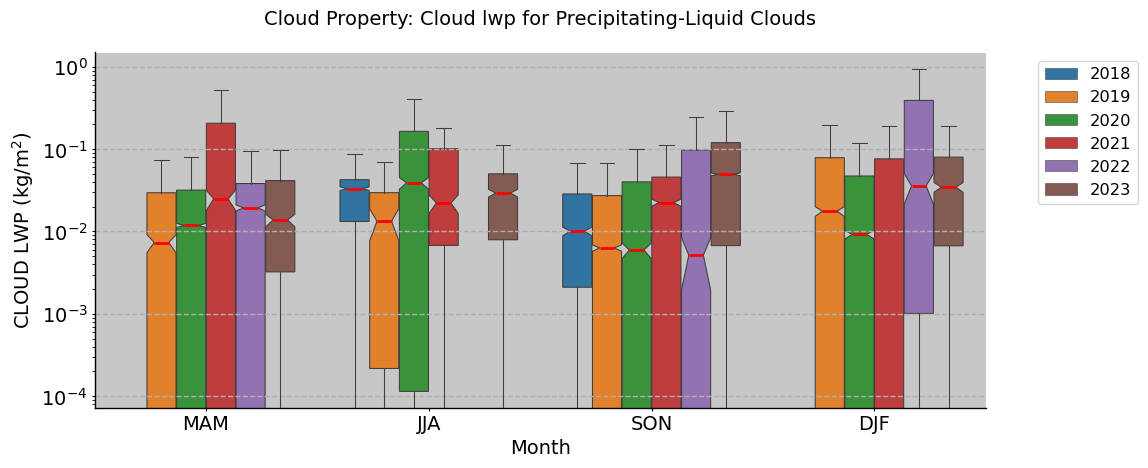

/tmp/ipykernel_872186/7138113.py:30: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


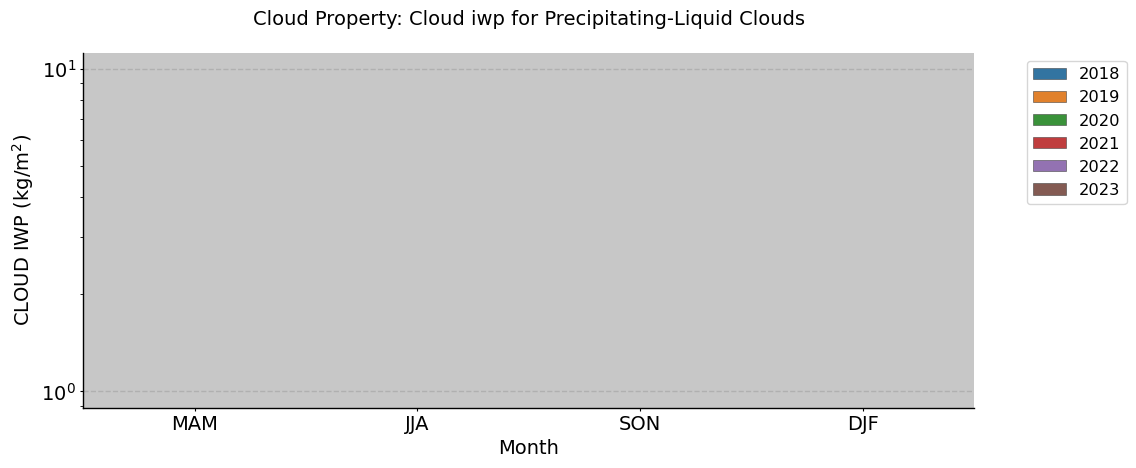

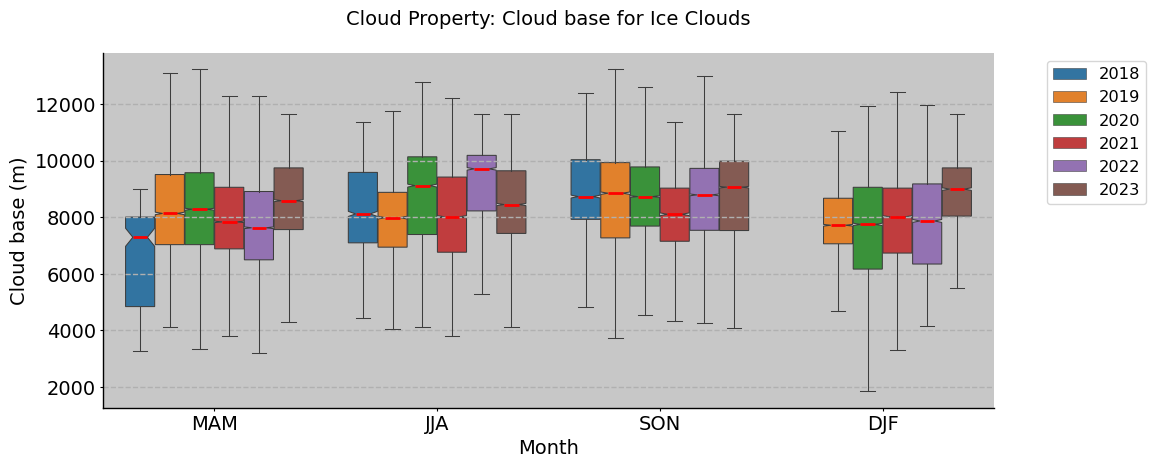

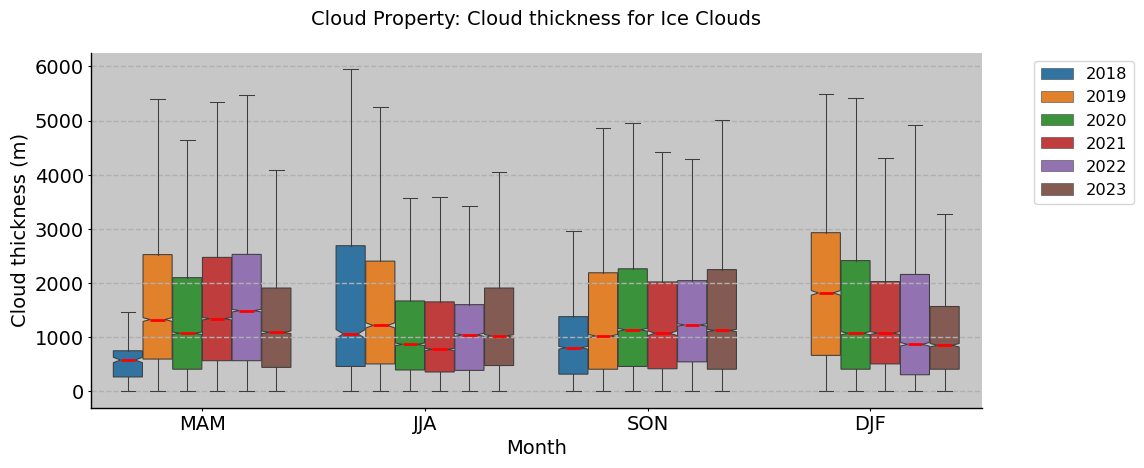

/tmp/ipykernel_872186/7138113.py:30: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


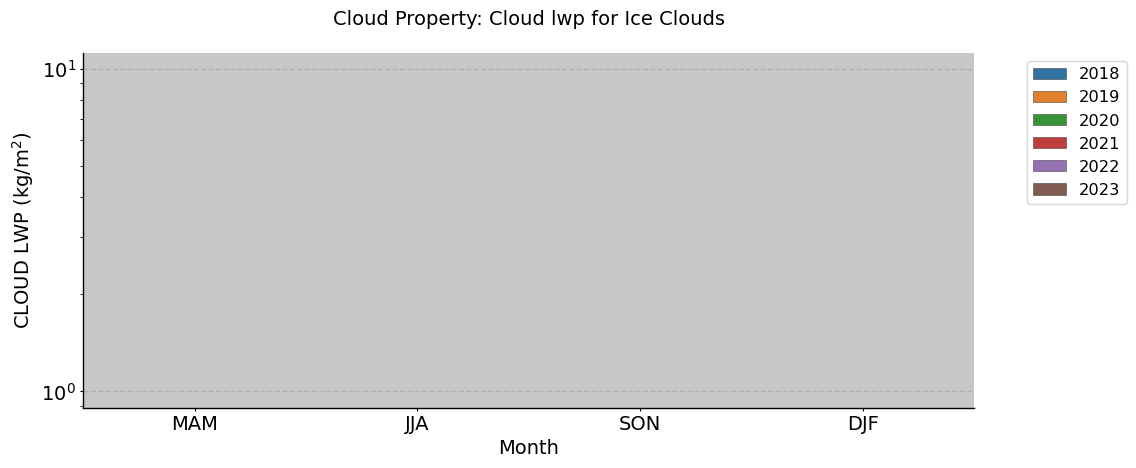

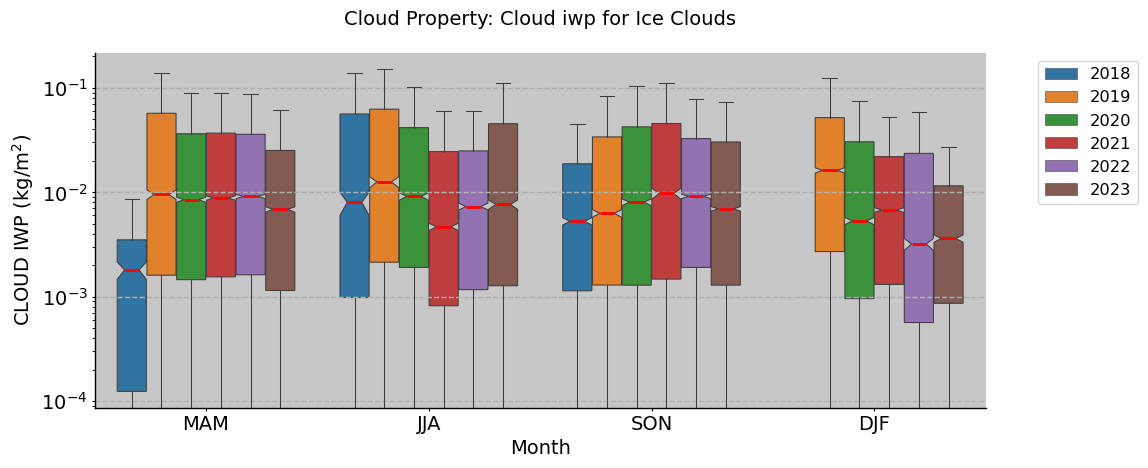

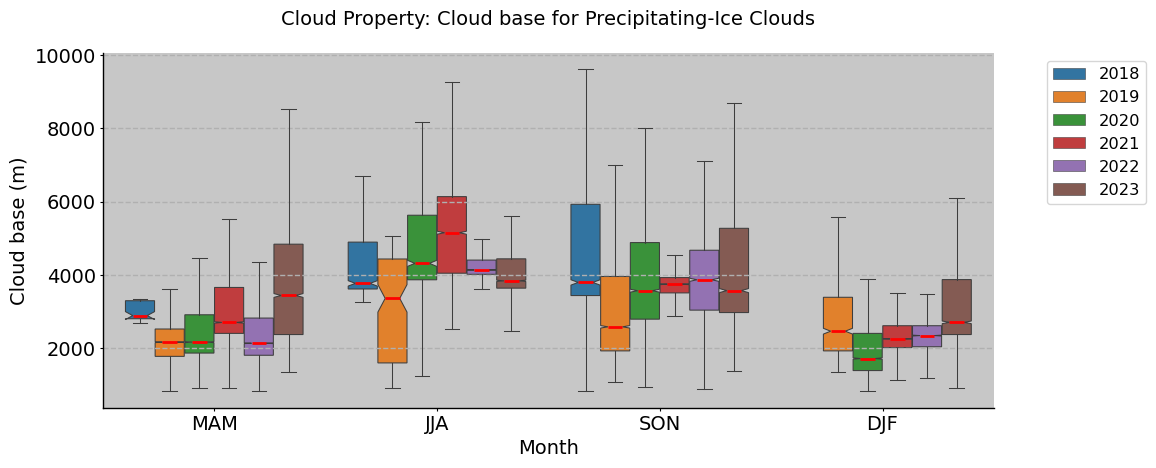

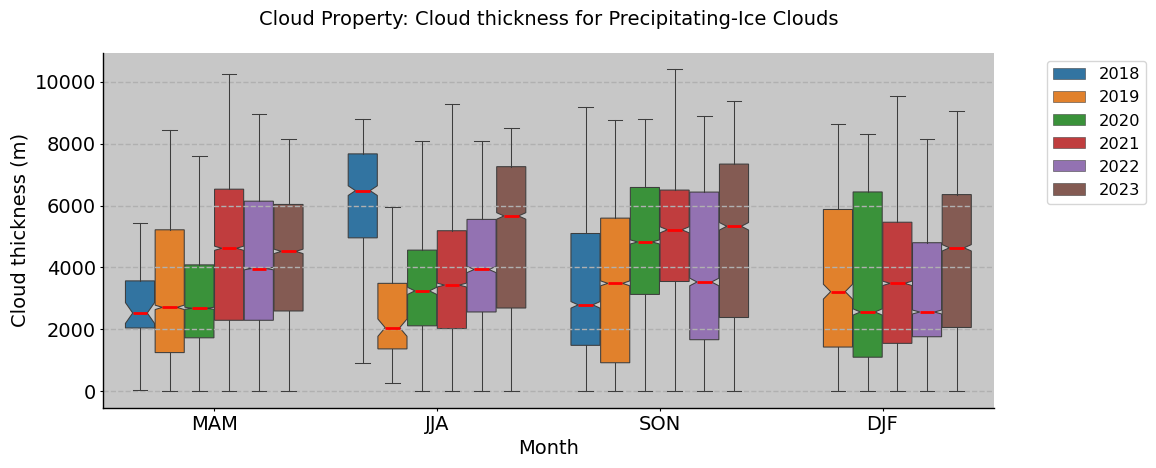

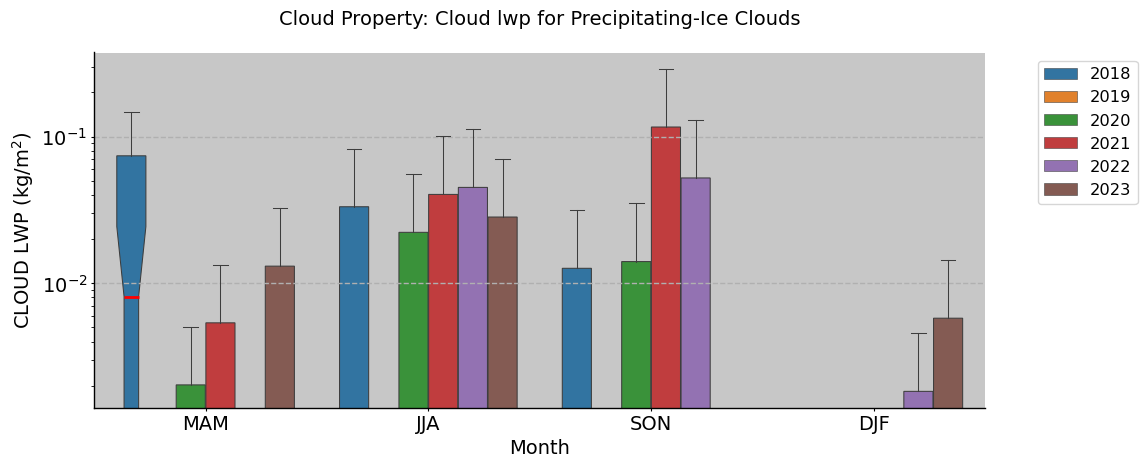

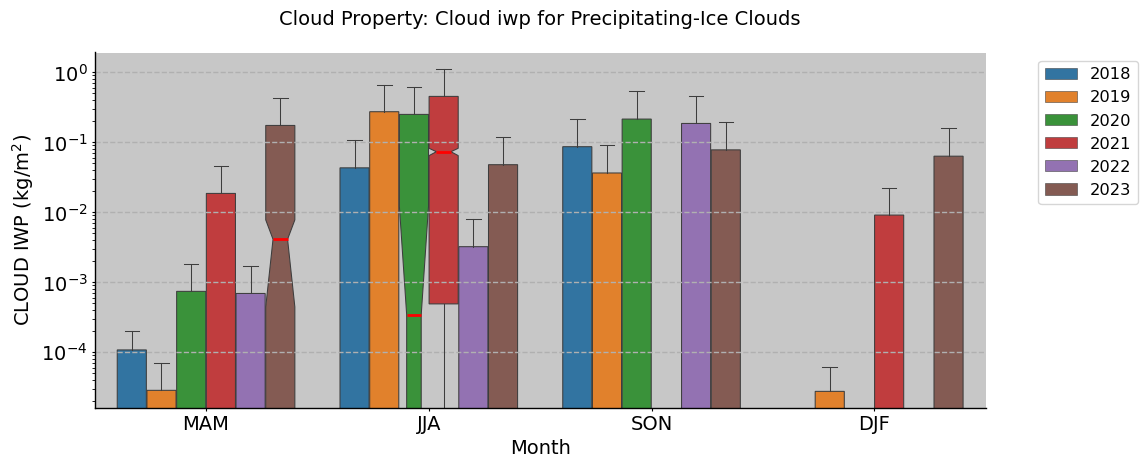

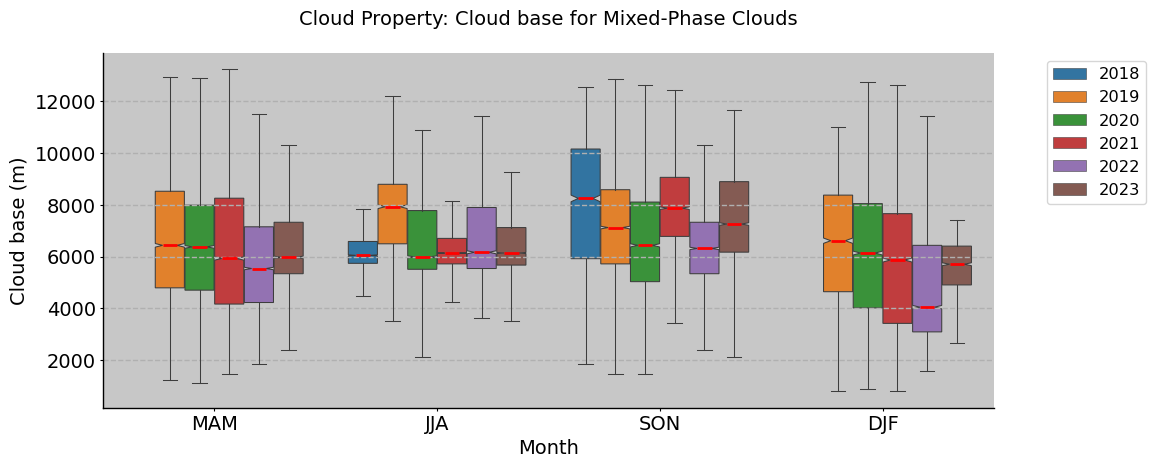

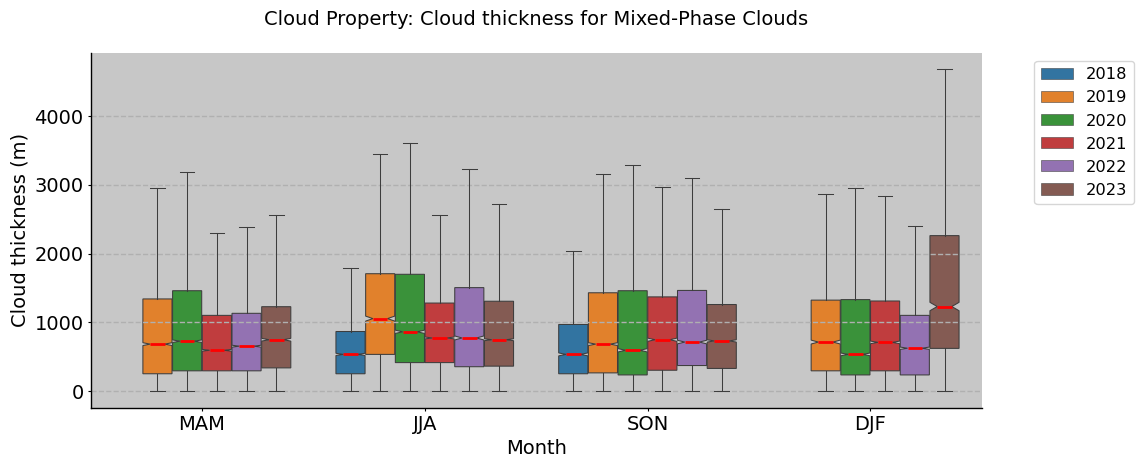

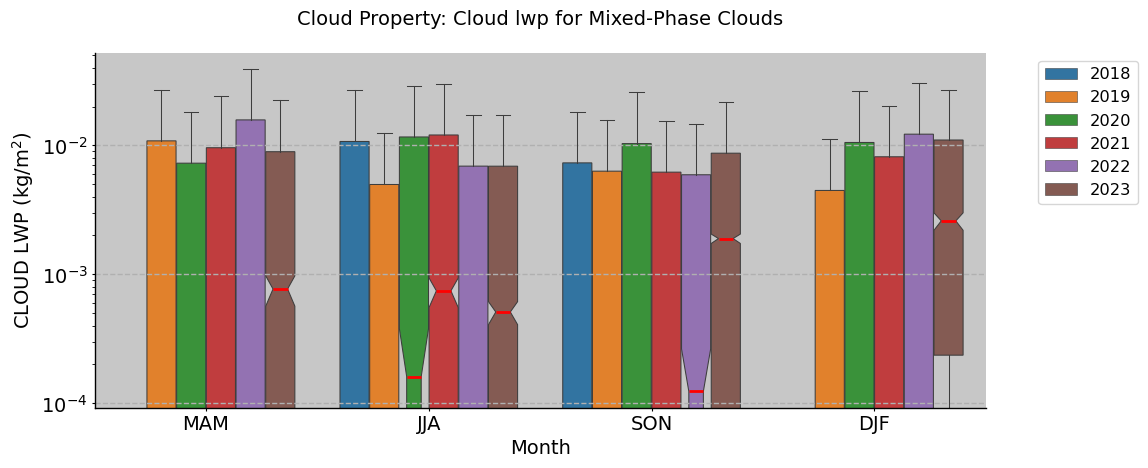

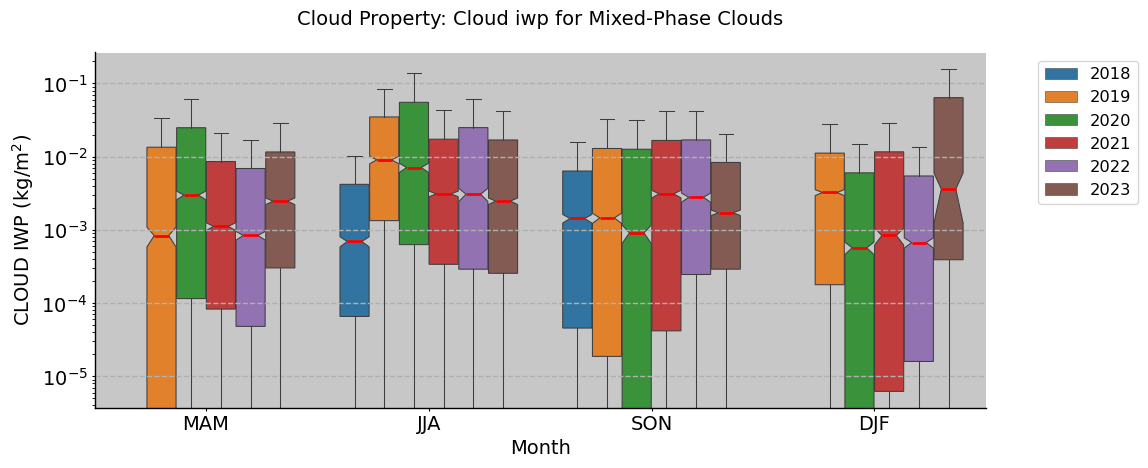

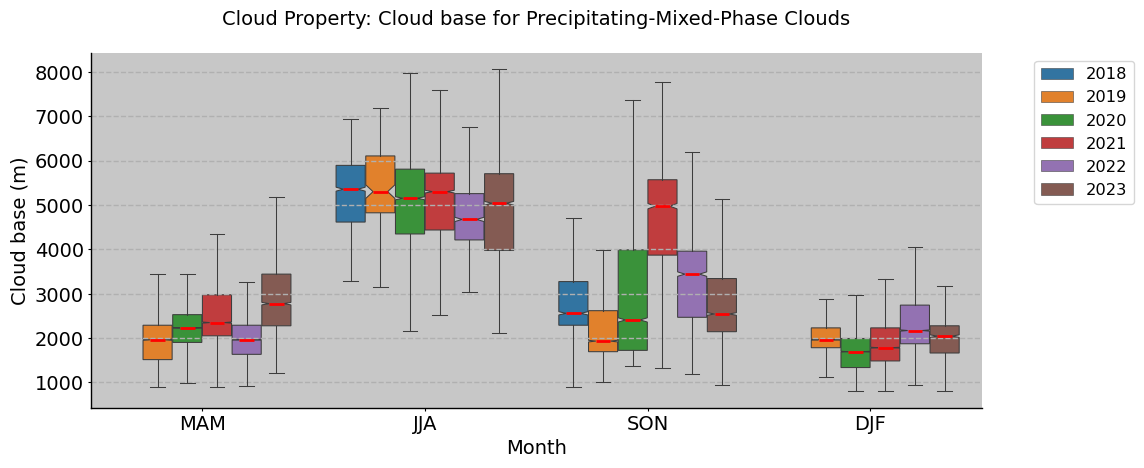

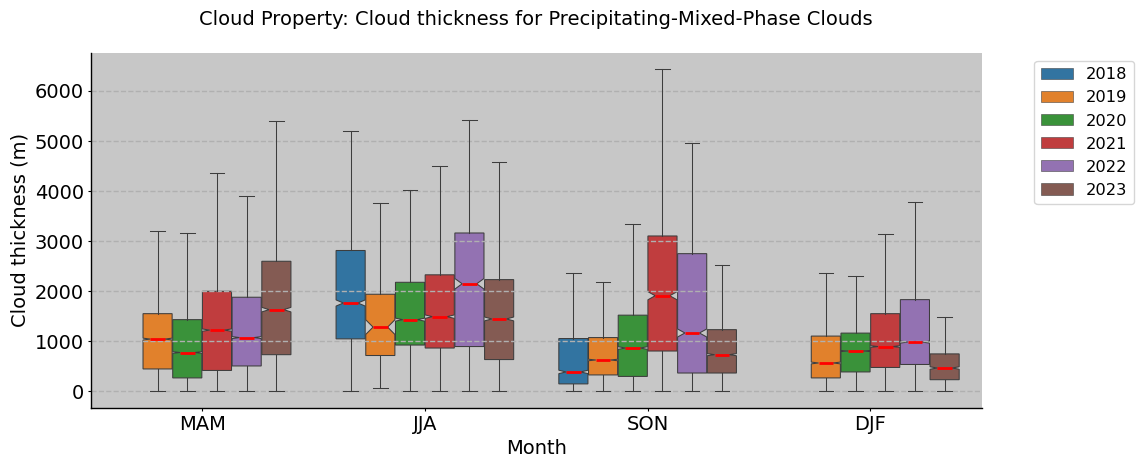

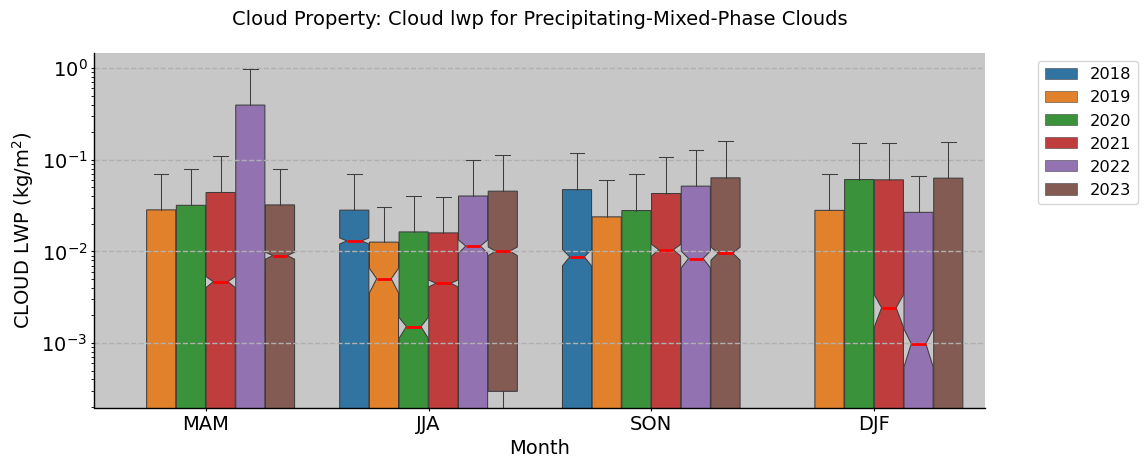

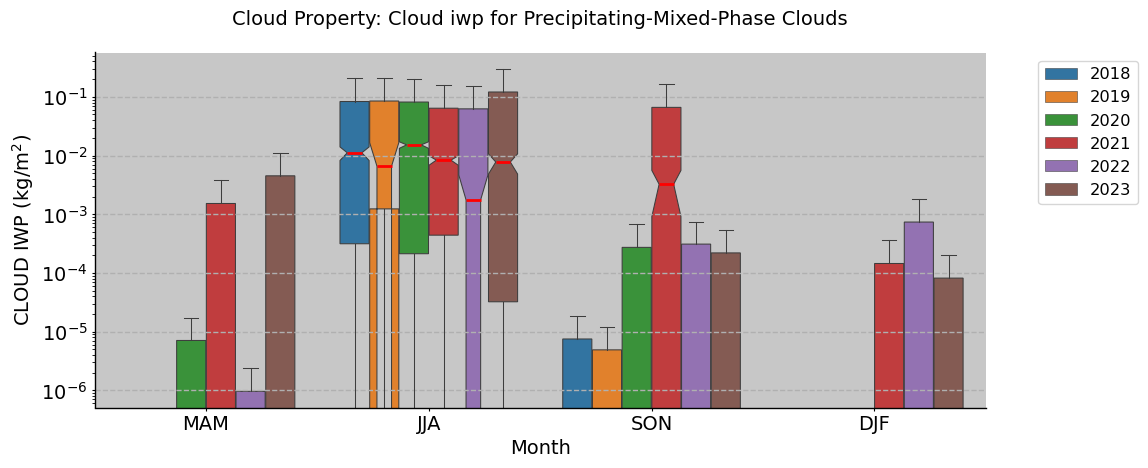

In [105]:
props = list(ds_prop_cba_single_layer.data_vars)
clouds = list(ds_ctp_cba.data_vars)[:-1]
years = np.unique(ds_prop['time'].dt.year)
for cloud in clouds:
    for p in props:
        # plot a comparison between PBA and CBA methods for each property p
        # Make year a coordinate of ds_prop_cba_single_layer
        ds_prop_cba_single_layer = ds_prop_cba_single_layer.assign_coords(years=ds_prop_cba_single_layer['time'].dt.year,
                                                                            month=ds_prop_cba_single_layer['time'].dt.month,
                                                                            season=ds_prop_cba_single_layer['time'].dt.season
                                                                            ).compute()
        
        ds_prop_cloud = ds_prop_cba_single_layer.where(ds_ctp_cba_single_layer[cloud] == 1.)
        
        fig, ax = plt.subplots(figsize=(11,5))
        #make a boxplot with years as a hue
        # remove outliers from the boxplot
        sns.boxplot(x='season', y=p, 
                    hue='years',
                    data=ds_prop_cloud.to_dataframe().reset_index(),
                    notch=True,
                    # boxprops={"facecolor": (.3, .5, .7, .5)},
                    linewidth=.75,
                    medianprops={"color": "r", "linewidth": 2}, 
                    showfliers=False,
                    ax=ax)
        ax.set_title(f'Cloud Property: {p.replace("_", " ").capitalize()} for {cloud} Clouds')
        ax.set_xlabel('Month')
        if p == 'cloud_lwp' or p == 'cloud_iwp':
            ax.set_yscale('log')
            ax.set_ylabel(p.replace('_', ' ').upper() + r' (kg/m$^2$)')
        else:
            ax.set_ylabel(p.replace('_', ' ').capitalize() + ' (m)')
        #move legend outside the plot
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
        # remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.show()
